In [1]:
# 1 : 23~25년도 개최 건수

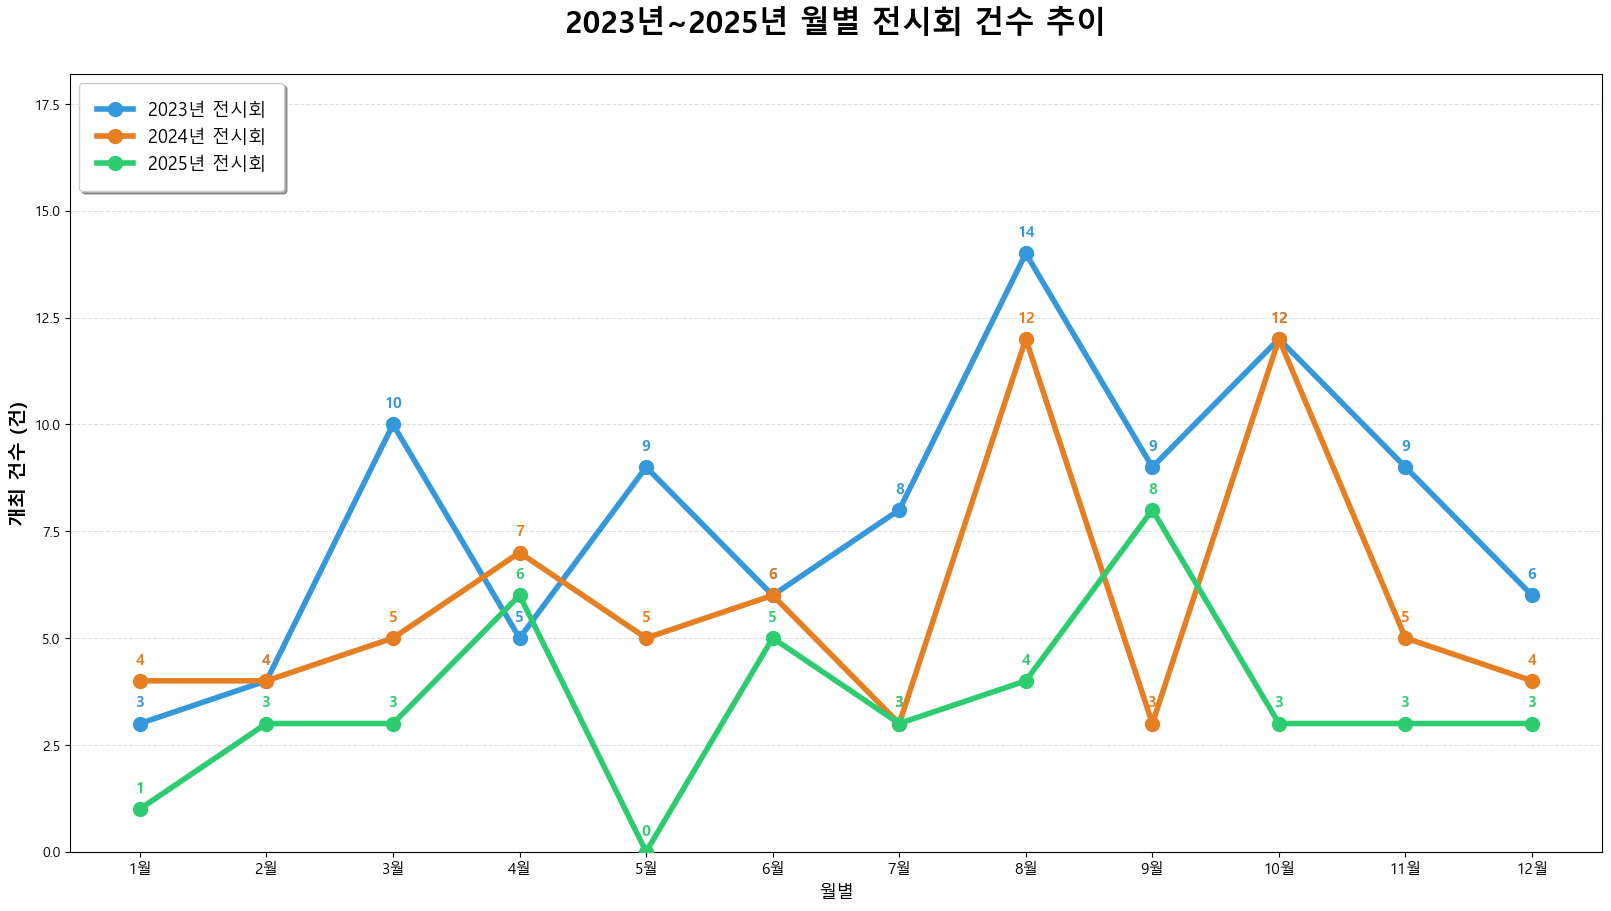

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 파일 리스트
files = {
    '2023': '2023년도 전시회 요약.csv',
    '2024': '2024년도 전시회 요약.csv',
    '2025': '2025년도 전시회 요약.csv'
}

try:
    # 3. 데이터 로드 및 정리
    yearly_exh = {}
    for year, file_name in files.items():
        df = pd.read_csv(file_name)
        # 첫 번째 행에서 1월~12월 개최 건수 추출
        yearly_exh[year] = df.iloc[0, 0:12].apply(pd.to_numeric).fillna(0)

    # 4. 시각화 설정
    months = [f'{i}월' for i in range(1, 13)]
    x = np.arange(len(months))

    fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)

    # 중앙 상단 제목
    plt.title('2023년~2025년 월별 전시회 건수 추이', fontsize=22, fontweight='bold', pad=30)

    # [디자인] 요청하신 색상으로 정확히 수정
    # 2023: 하늘색 / 2024: 주황색 / 2025: 초록색
    design_map = {
        '2023': {'color': '#3498db', 'label': '2023년 전시회'},
        '2024': {'color': '#e67e22', 'label': '2024년 전시회'},
        '2025': {'color': '#2ecc71', 'label': '2025년 전시회'}
    }

    for year in ['2023', '2024', '2025']:
        data = yearly_exh[year]
        style = design_map[year]
        
        # 꺾은선 그래프 (두께 4, 모든 마커 동그라미 'o')
        ax.plot(x, data, color=style['color'], marker='o', linestyle='-', 
                linewidth=4, markersize=10, label=style['label'], zorder=3)

        # 수치 표시 (점 바로 위)
        for i, val in enumerate(data):
            ax.text(i, val + 0.3, f'{int(val)}', ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', color=style['color'])

    # 5. 축 및 레이아웃 설정
    ax.set_ylabel('개최 건수 (건)', fontsize=14, fontweight='bold')
    ax.set_xlabel('월별', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(months, fontsize=11)
    
    # 범례 설정 (좌측 상단, 그림자 효과)
    ax.legend(loc='upper left', fontsize=13, frameon=True, shadow=True, borderpad=1)

    # 배경 그리드 (점선)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
    
    # Y축 범위 최적화
    all_values = pd.concat([yearly_exh['2023'], yearly_exh['2024'], yearly_exh['2025']])
    ax.set_ylim(0, all_values.max() * 1.3)

    plt.show()

except Exception as e:
    print(f"데이터 로드 중 오류 발생: {e}")

In [3]:
# 2 상권분석 & 호텔분석 with 개최건수

In [4]:
import pandas as pd
import os

# 1. 통합할 파일 리스트 설정
# 사용자가 업로드한 파일명에 맞춰 리스트를 생성합니다.
file_list = [
    '20260408092010_관광소비 추이.csv',  # 송도1동
    '20260408092535_관광소비 추이.csv',  # 송도2동
    '20260408092619_관광소비 추이.csv',  # 송도3동
    '20260408092938_관광소비 추이.csv',  # 송도4동
    '20260408093018_관광소비 추이.csv'   # 송도5동
]

def merge_tourism_consumption_files(files, output_filename):
    all_data = []
    
    for file in files:
        try:
            # CSV 파일 읽기
            # 데이터에 한글이 포함되어 있으므로 cp949 또는 utf-8-sig 인코딩을 주로 사용합니다.
            df = pd.read_csv(file, encoding='utf-8')
            all_data.append(df)
            print(f"성공적으로 로드됨: {file}")
        except Exception as e:
            print(f"파일 로드 실패 ({file}): {e}")

    if all_data:
        # 2. 데이터 통합 (세로로 합치기)
        merged_df = pd.concat(all_data, ignore_index=True)
        
        # 3. 통합된 데이터를 CSV 파일로 저장
        # 한글 깨짐 방지를 위해 utf-8-sig 인코딩을 사용합니다.
        merged_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
        print(f"\n--- 통합 완료! ---")
        print(f"저장된 파일명: {output_filename}")
        print(f"전체 데이터 행 수: {len(merged_df)}개")
        
        return merged_df
    else:
        print("통합할 데이터가 없습니다.")
        return None

# 코드 실행
output_file = '송도_통합_관광소비_현황_2023.csv'
final_df = merge_tourism_consumption_files(file_list, output_file)

# 통합된 데이터의 앞부분 확인 (선택 사항)
if final_df is not None:
    print("\n[통합 데이터 샘플]")
    print(final_df.head())

성공적으로 로드됨: 20260408092010_관광소비 추이.csv
성공적으로 로드됨: 20260408092535_관광소비 추이.csv
성공적으로 로드됨: 20260408092619_관광소비 추이.csv
성공적으로 로드됨: 20260408092938_관광소비 추이.csv
성공적으로 로드됨: 20260408093018_관광소비 추이.csv

--- 통합 완료! ---
저장된 파일명: 송도_통합_관광소비_현황_2023.csv
전체 데이터 행 수: 751개

[통합 데이터 샘플]
     기준년월  행정동명    중분류     소비액(천원)
0  202301  송도1동  관광총소비   9962211.0
1  202302  송도1동  관광총소비  10068517.0
2  202303  송도1동  관광총소비  12002571.0
3  202304  송도1동  관광총소비  12777159.0
4  202305  송도1동  관광총소비  13930089.0


In [5]:
import pandas as pd

# 1. 2024년 통합할 파일 리스트 (업로드하신 파일명 기준)
file_list_2024 = [
    '20260408092044_관광소비 추이.csv',  # 송도1동 (24년)
    '20260408092440_관광소비 추이.csv',  # 송도2동 (24년)
    '20260408092710_관광소비 추이.csv',  # 송도3동 (24년)
    '20260408092846_관광소비 추이.csv',  # 송도4동 (24년)
    '20260408093051_관광소비 추이.csv'   # 송도5동 (24년)
]

def merge_2024_data(files, output_filename):
    all_data = []
    
    for file in files:
        try:
            # 한글 깨짐 방지를 위해 utf-8 또는 cp949 시도
            df = pd.read_csv(file, encoding='utf-8')
            all_data.append(df)
            print(f"로드 완료: {file}")
        except Exception as e:
            print(f"로드 실패 ({file}): {e}")

    if all_data:
        # 2. 데이터 세로 통합
        merged_df = pd.concat(all_data, ignore_index=True)
        
        # 3. 엑셀 호환을 위해 utf-8-sig로 저장
        merged_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
        print(f"\n--- 2024년 통합 완료! ---")
        print(f"저장된 파일명: {output_filename}")
        return merged_df
    else:
        print("통합할 데이터가 없습니다.")
        return None

# 코드 실행
output_file_2024 = '송도_통합_관광소비_현황_2024.csv'
final_df_2024 = merge_2024_data(file_list_2024, output_file_2024)

# 데이터 확인
if final_df_2024 is not None:
    print(final_df_2024.head())

로드 완료: 20260408092044_관광소비 추이.csv
로드 완료: 20260408092440_관광소비 추이.csv
로드 완료: 20260408092710_관광소비 추이.csv
로드 완료: 20260408092846_관광소비 추이.csv
로드 완료: 20260408093051_관광소비 추이.csv

--- 2024년 통합 완료! ---
저장된 파일명: 송도_통합_관광소비_현황_2024.csv
     기준년월  행정동명    중분류     소비액(천원)
0  202401  송도1동  관광총소비   9826152.0
1  202402  송도1동  관광총소비   9617208.0
2  202403  송도1동  관광총소비  14070980.0
3  202404  송도1동  관광총소비  11879504.0
4  202405  송도1동  관광총소비  13356947.0


In [6]:
import pandas as pd

# 1. 2025년 통합할 파일 리스트 (새로 업로드하신 파일명 기준)
file_list_2025 = [
    '20260408092123_관광소비 추이.csv',  # 송도1동 (25년)
    '20260408092415_관광소비 추이.csv',  # 송도2동 (25년)
    '20260408092736_관광소비 추이.csv',  # 송도3동 (25년)
    '20260408092818_관광소비 추이.csv',  # 송도4동 (25년)
    '20260408093110_관광소비 추이.csv'   # 송도5동 (25년)
]

def merge_2025_data(files, output_filename):
    all_data = []
    
    for file in files:
        try:
            # 한글 인코딩 대응 (utf-8 우선 시도)
            df = pd.read_csv(file, encoding='utf-8')
            all_data.append(df)
            print(f"로드 성공: {file}")
        except Exception as e:
            print(f"로드 실패 ({file}): {e}")

    if all_data:
        # 2. 데이터 세로 통합
        merged_df = pd.concat(all_data, ignore_index=True)
        
        # 3. 엑셀에서 바로 열어도 한글이 안 깨지도록 utf-8-sig 저장
        merged_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
        print(f"\n--- 2025년 데이터 통합 완료! ---")
        print(f"저장된 파일명: {output_filename}")
        print(f"총 데이터 행 수: {len(merged_df)}행")
        return merged_df
    else:
        print("통합할 데이터가 없습니다.")
        return None

# 코드 실행
output_file_2025 = '송도_통합_관광소비_현황_2025.csv'
final_df_2025 = merge_2025_data(file_list_2025, output_file_2025)

# 데이터 상위 5줄 확인
if final_df_2025 is not None:
    print("\n[통합 데이터 샘플]")
    print(final_df_2025.head())

로드 성공: 20260408092123_관광소비 추이.csv
로드 성공: 20260408092415_관광소비 추이.csv
로드 성공: 20260408092736_관광소비 추이.csv
로드 성공: 20260408092818_관광소비 추이.csv
로드 성공: 20260408093110_관광소비 추이.csv

--- 2025년 데이터 통합 완료! ---
저장된 파일명: 송도_통합_관광소비_현황_2025.csv
총 데이터 행 수: 779행

[통합 데이터 샘플]
     기준년월  행정동명    중분류     소비액(천원)
0  202501  송도1동  관광총소비   9193954.0
1  202502  송도1동  관광총소비   8419620.0
2  202503  송도1동  관광총소비  11206856.0
3  202504  송도1동  관광총소비  11604176.0
4  202505  송도1동  관광총소비  12733208.0


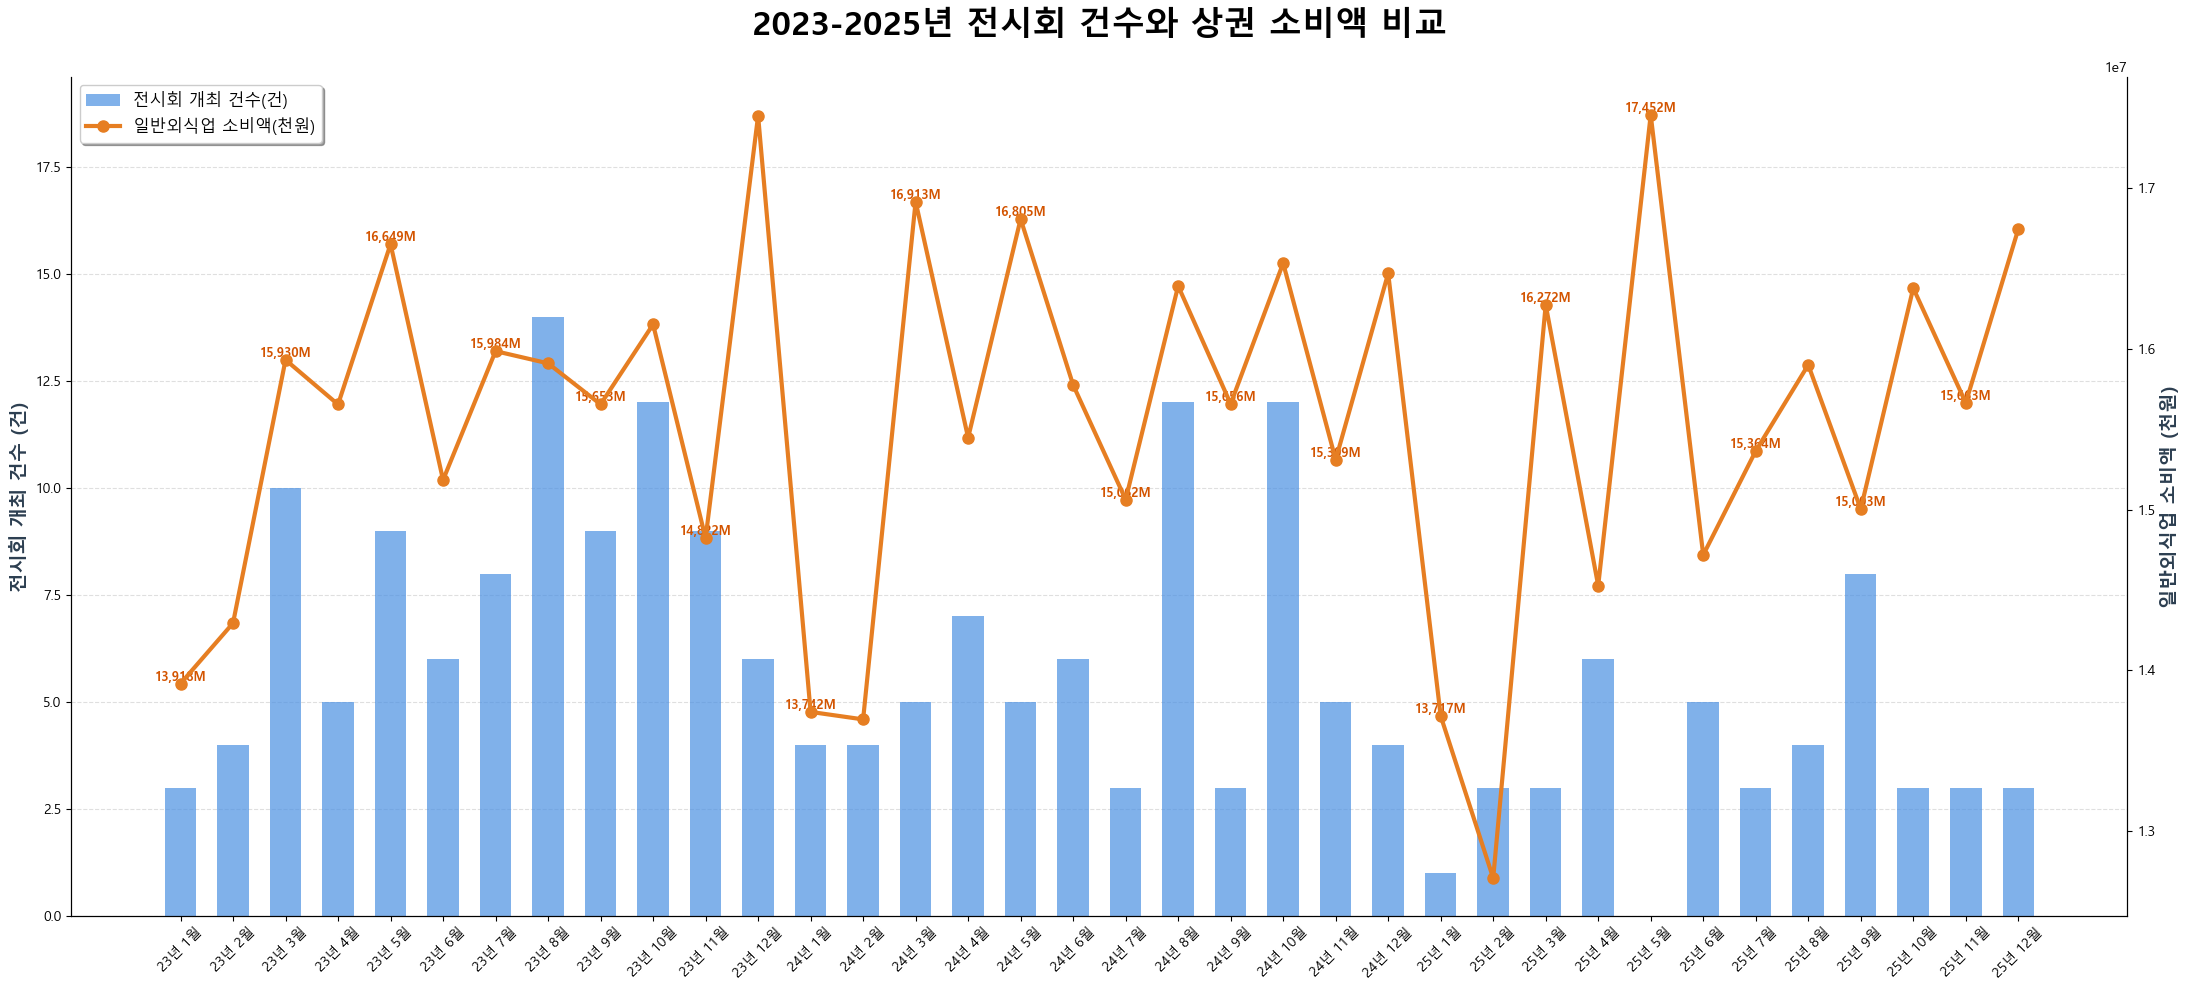

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비 함수
def load_and_process_data():
    years = ['2023', '2024', '2025']
    all_consumption = []
    all_exhibitions = []
    time_labels = []

    for year in years:
        # A. 소비 데이터 로드 및 '일반외식업' 추출
        c_df = pd.read_csv(f'송도_통합_관광소비_현황_{year}.csv')
        food_df = c_df[c_df['중분류'] == '일반외식업']
        food_monthly = food_df.groupby('기준년월')['소비액(천원)'].sum().reset_index()
        all_consumption.extend(food_monthly['소비액(천원)'].tolist())

        # B. 전시회 데이터 로드
        e_df = pd.read_csv(f'{year}년도 전시회 요약.csv')
        exh_counts = e_df.iloc[0, 0:12].apply(pd.to_numeric).values
        all_exhibitions.extend(exh_counts)

        # C. X축 레이블 생성
        for month in range(1, 13):
            time_labels.append(f"{year[-2:]}년 {month}월")

    return time_labels, all_consumption, all_exhibitions

# 데이터 로드
labels, consumption, exhibitions = load_and_process_data()
x = np.arange(len(labels))

# 3. 그래프 시각화
fig, ax1 = plt.subplots(figsize=(22, 10))

# --- 막대 그래프: 전시회 개최 건수 (수정: 맑은 파란색 계열) ---
# #4A90E2는 신뢰감을 주면서도 너무 어둡지 않은 스카이 블루/로열 블루 톤입니다.
bars = ax1.bar(x, exhibitions, color='#4A90E2', alpha=0.7, width=0.6, label='전시회 개최 건수(건)', zorder=2)
ax1.set_ylabel('전시회 개최 건수 (건)', fontsize=14, fontweight='bold', color='#2C3E50')
ax1.set_ylim(0, max(exhibitions) * 1.4)

# --- 꺾은선 그래프: 일반외식업 소비액 (오른쪽 Y축) ---
ax2 = ax1.twinx()
line = ax2.plot(x, consumption, color='#E67E22', marker='o', linewidth=3, 
                markersize=8, label='일반외식업 소비액(천원)', zorder=5)
ax2.set_ylabel('일반외식업 소비액 (천원)', fontsize=14, fontweight='bold', color='#2C3E50')

# 4. 디자인 세부 설정 (사진 형식 유지)
plt.title('2023-2025년 전시회 건수와 상권 소비액 비교', fontsize=24, fontweight='bold', pad=30)

# X축 설정 (45도 회전)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, fontsize=10)

# 범례 설정 (테두리 및 그림자 포함)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12, frameon=True, shadow=True)

# 그리드 및 테두리 설정
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# 소비액 수치 표시 (2개월 간격)
for i, val in enumerate(consumption):
    if i % 2 == 0:
        ax2.text(i, val, f'{int(val/1000):,}M', ha='center', va='bottom', 
                 fontsize=9, fontweight='bold', color='#D35400')

plt.tight_layout()
plt.show()

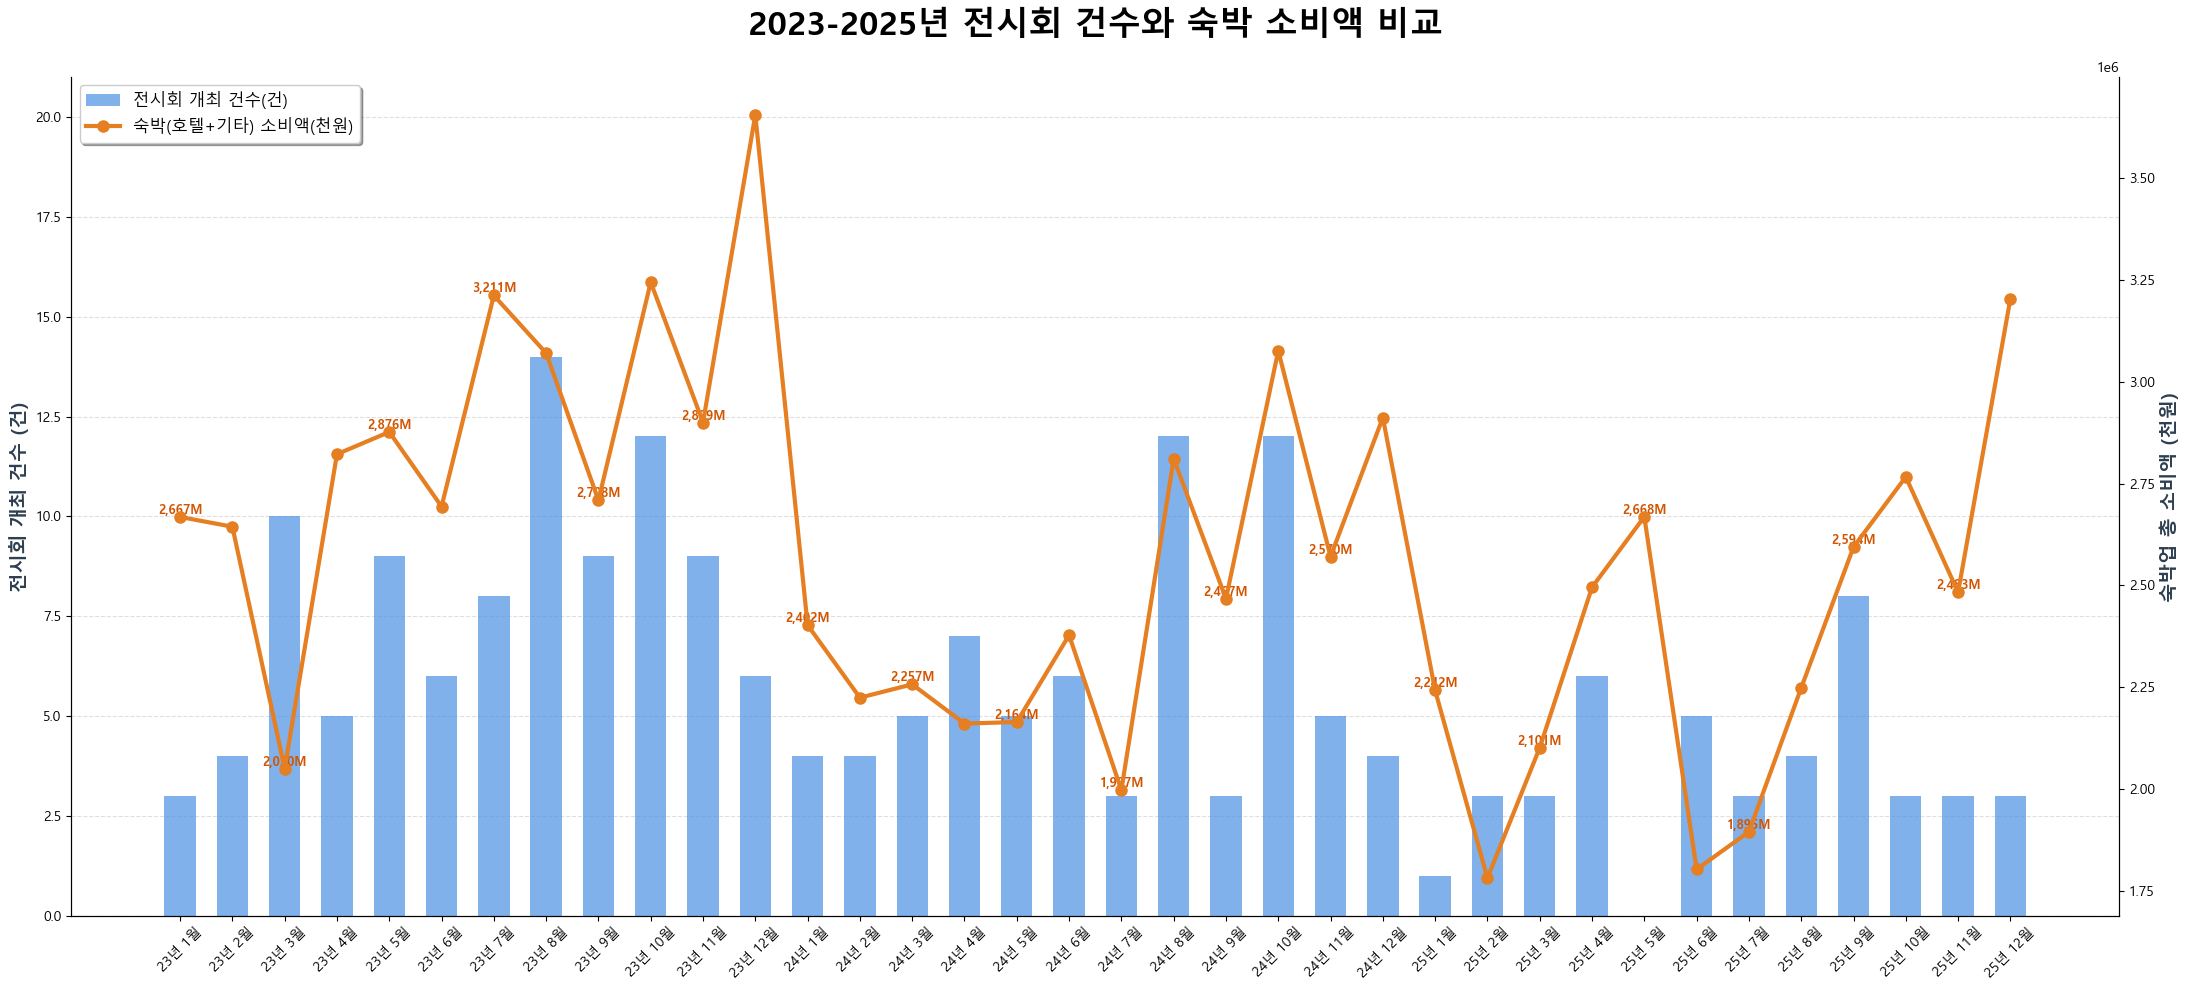

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 폰트 설정 (환경에 맞춰 수정하세요)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비 함수
def load_and_process_data():
    years = ['2023', '2024', '2025']
    all_accommodation_spending = [] # 호텔 + 기타숙박 합산 리스트
    all_exhibitions = []           # 전시회 건수 리스트
    time_labels = []               # X축 레이블

    for year in years:
        # A. 소비 데이터 로드 및 '호텔', '기타숙박' 합산 추출
        c_df = pd.read_csv(f'송도_통합_관광소비_현황_{year}.csv')
        
        # 호텔과 기타숙박 데이터만 필터링하여 합산
        stay_df = c_df[c_df['중분류'].isin(['호텔', '기타숙박'])]
        stay_monthly = stay_df.groupby('기준년월')['소비액(천원)'].sum().reset_index()
        
        all_accommodation_spending.extend(stay_monthly['소비액(천원)'].tolist())

        # B. 전시회 데이터 로드 (파일 경로 확인 필요)
        try:
            e_df = pd.read_csv(f'{year}년도 전시회 요약.csv')
            exh_counts = e_df.iloc[0, 0:12].apply(pd.to_numeric).values
            all_exhibitions.extend(exh_counts)
        except FileNotFoundError:
            # 전시회 파일이 없을 경우 0으로 채움 (테스트용)
            all_exhibitions.extend([0]*12)

        # C. X축 레이블 생성
        for month in range(1, 13):
            time_labels.append(f"{year[-2:]}년 {month}월")

    return time_labels, all_accommodation_spending, all_exhibitions

# 데이터 로드 실행
labels, stay_spending, exhibitions = load_and_process_data()
x = np.arange(len(labels))

# 3. 그래프 시각화 (이전과 동일한 레이아웃)
fig, ax1 = plt.subplots(figsize=(22, 10))

# --- 막대 그래프: 전시회 개최 건수 (맑은 파란색) ---
bars = ax1.bar(x, exhibitions, color='#4A90E2', alpha=0.7, width=0.6, 
               label='전시회 개최 건수(건)', zorder=2)
ax1.set_ylabel('전시회 개최 건수 (건)', fontsize=14, fontweight='bold', color='#2C3E50')
ax1.set_ylim(0, max(exhibitions) * 1.5) # 여유 공간 확보

# --- 꺾은선 그래프: 호텔+기타숙박 소비액 (오른쪽 Y축, 오렌지색) ---
ax2 = ax1.twinx()
line = ax2.plot(x, stay_spending, color='#E67E22', marker='o', linewidth=3, 
                markersize=8, label='숙박(호텔+기타) 소비액(천원)', zorder=5)
ax2.set_ylabel('숙박업 총 소비액 (천원)', fontsize=14, fontweight='bold', color='#2C3E50')

# 4. 디자인 세부 설정
plt.title('2023-2025년 전시회 건수와 숙박 소비액 비교', fontsize=24, fontweight='bold', pad=30)

# X축 레이블 (45도 회전)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, fontsize=10)

# 범례 통합 표시
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12, frameon=True, shadow=True)

# 그리드 및 스파인 제거
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# 소비액 수치 표시 (가독성을 위해 2개월 간격 표시)
for i, val in enumerate(stay_spending):
    if i % 2 == 0:
        ax2.text(i, val, f'{int(val/1000):,}M', ha='center', va='bottom', 
                 fontsize=9, fontweight='bold', color='#D35400')

plt.tight_layout()
plt.show()

In [9]:
# 3

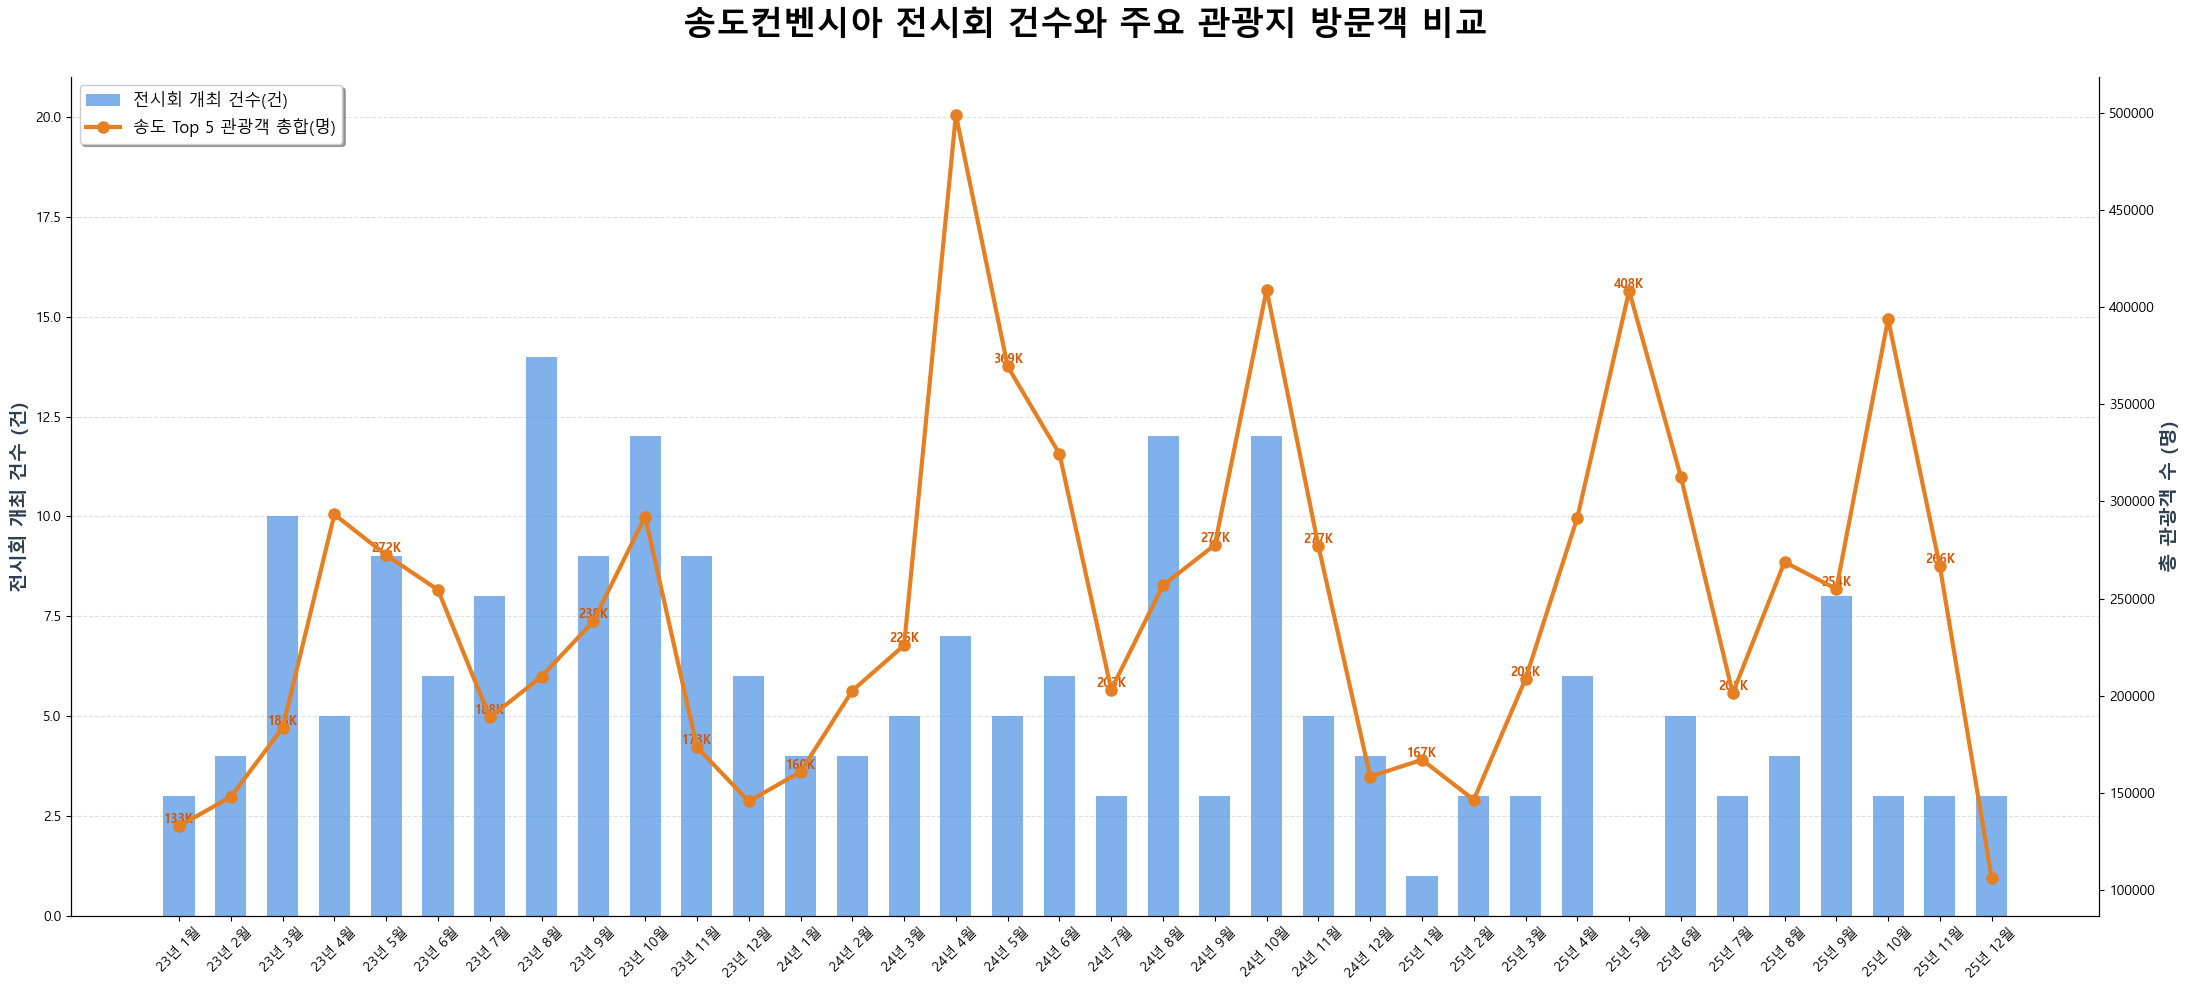

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비 함수
def load_and_process_data():
    years = ['2023', '2024', '2025']
    all_tourists = []      # Top 5 관광지 관광객 총합 리스트
    all_exhibitions = []   # 전시회 건수 리스트
    time_labels = []       # X축 레이블

    # A. 관광지 데이터 로드 및 전처리
    tour_df = pd.read_csv('Top5_관광지_상세내역(중복제거).csv')
    
    # [수정] 파일 구조상 실제 숫자가 들어있는 열 인덱스 (Unnamed 필드 위주)
    # 2023년(6~17), 2024년(19~30), 2025년(32~43)
    tourist_indices = [list(range(6, 18)), list(range(19, 31)), list(range(32, 44))]
    
    for i, year in enumerate(years):
        # 해당 연도의 12개월 데이터 슬라이싱
        year_cols = tour_df.iloc[:, tourist_indices[i]]
        
        # [핵심 수정] 에러 방지 로직:
        # 1. 모든 데이터를 문자열로 변환 후 콤마(,) 제거
        # 2. pd.to_numeric의 errors='coerce'를 사용해 숫자가 아닌 값은 NaN으로 변환
        # 3. fillna(0)로 NaN을 0으로 처리하여 계산 가능하게 만듦
        cleaned_data = year_cols.replace({',': ''}, regex=True)
        numeric_data = cleaned_data.apply(pd.to_numeric, errors='coerce').fillna(0)
        
        # 5개 관광지(모든 행)의 월별 합계 계산
        monthly_sum = numeric_data.sum(axis=0).tolist()
        all_tourists.extend(monthly_sum)

        # B. 전시회 데이터 로드 (기존 유지)
        try:
            e_df = pd.read_csv(f'{year}년도 전시회 요약.csv')
            exh_counts = e_df.iloc[0, 0:12].apply(pd.to_numeric, errors='coerce').fillna(0).values
            all_exhibitions.extend(exh_counts)
        except FileNotFoundError:
            all_exhibitions.extend([0]*12)

        # C. X축 레이블 생성
        for month in range(1, 13):
            time_labels.append(f"{year[-2:]}년 {month}월")

    return time_labels, all_tourists, all_exhibitions

# 데이터 로드 실행
try:
    labels, total_tourists, exhibitions = load_and_process_data()
    x = np.arange(len(labels))

    # 3. 그래프 시각화 (요청하신 레이아웃 형식 유지)
    fig, ax1 = plt.subplots(figsize=(22, 10))

    # --- 막대 그래프: 전시회 개최 건수 (맑은 파란색) ---
    bars = ax1.bar(x, exhibitions, color='#4A90E2', alpha=0.7, width=0.6, 
                   label='전시회 개최 건수(건)', zorder=2)
    ax1.set_ylabel('전시회 개최 건수 (건)', fontsize=14, fontweight='bold', color='#2C3E50')
    ax1.set_ylim(0, max(exhibitions) * 1.5 if len(exhibitions)>0 else 10)

    # --- 꺾은선 그래프: Top 5 관광지 총 관광객 수 (오른쪽 Y축, 오렌지색) ---
    ax2 = ax1.twinx()
    line = ax2.plot(x, total_tourists, color='#E67E22', marker='o', linewidth=3, 
                    markersize=8, label='송도 Top 5 관광객 총합(명)', zorder=5)
    ax2.set_ylabel('총 관광객 수 (명)', fontsize=14, fontweight='bold', color='#2C3E50')

    # 4. 디자인 세부 설정
    plt.title('송도컨벤시아 전시회 건수와 주요 관광지 방문객 비교', fontsize=24, fontweight='bold', pad=30)

    # X축 레이블
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, fontsize=10)

    # 범례 통합
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12, frameon=True, shadow=True)

    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    # 방문객 수치 표시 (2개월 간격, 천 단위 표기)
    for i, val in enumerate(total_tourists):
        if i % 2 == 0:
            ax2.text(i, val, f'{int(val/1000):,}K', ha='center', va='bottom', 
                     fontsize=9, fontweight='bold', color='#D35400')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"오류가 발생했습니다: {e}")

In [11]:
#4

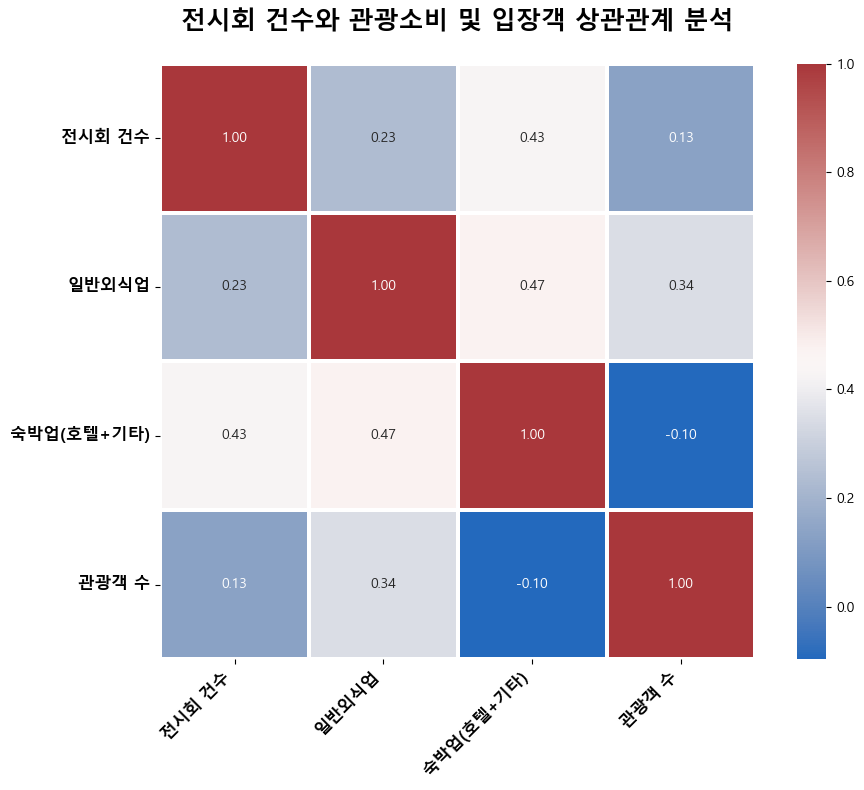

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. 한글 폰트 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def load_processed_data():
    years = ['2023', '2024', '2025']
    combined_list = []

    # 관광지 데이터 로드
    tour_df = pd.read_csv('Top5_관광지_상세내역(중복제거).csv')
    tourist_indices = {'2023': range(6, 18), '2024': range(19, 31), '2025': range(32, 44)}

    for year in years:
        # A. 소비 데이터 로드 및 전처리 (외식, 숙박 합산)
        c_df = pd.read_csv(f'송도_통합_관광소비_현황_{year}.csv')
        pivot = c_df.groupby(['기준년월', '중분류'])['소비액(천원)'].sum().unstack()
        
        # '호텔'과 '기타숙박'을 합쳐서 '숙박업' 데이터 생성
        pivot['숙박업(합계)'] = pivot.get('호텔', 0) + pivot.get('기타숙박', 0)
        spending_data = pivot[['일반외식업', '숙박업(합계)']].reset_index()

        # B. 전시회 데이터 로드
        try:
            e_df = pd.read_csv(f'{year}년도 전시회 요약.csv')
            exh_counts = e_df.iloc[0, 0:12].apply(pd.to_numeric, errors='coerce').fillna(0).values
        except:
            exh_counts = [0] * 12

        # C. 관광객 수 데이터 추출
        y_tour_cols = tour_df.iloc[:, tourist_indices[year]]
        y_tour_numeric = y_tour_cols.replace({',': ''}, regex=True).apply(pd.to_numeric, errors='coerce').fillna(0)
        monthly_tourists = y_tour_numeric.sum(axis=0).values

        # 데이터 병합
        for i in range(12):
            combined_list.append({
                '전시회 건수': exh_counts[i],
                '일반외식업': spending_data.iloc[i]['일반외식업'],
                '숙박업(호텔+기타)': spending_data.iloc[i]['숙박업(합계)'],
                '관광객 수': monthly_tourists[i]
            })

    return pd.DataFrame(combined_list)

# 데이터 준비 및 상관계수 계산
df_final = load_processed_data()
corr = df_final.corr()

# --- 컬러 및 스타일 설정 ---
# 양의 상관관계(#D32F2F), 음의 상관관계(#1976D2) 커스텀 컬러맵
colors = ["#1976D2", "#FFFFFF", "#D32F2F"]
custom_cmap = LinearSegmentedColormap.from_list("custom_refined", colors)

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))

sns.heatmap(corr, 
            annot=True, 
            fmt=".2f", 
            cmap='vlag',         # 부드러운 감성 테마
            linewidths=1.5,        # 칸 사이를 넓게 벌려서 '조각' 느낌 주기
            linecolor='white',   # 배경과 같은 흰색 선
            square=True)

plt.title('전시회 건수와 관광소비 및 입장객 상관관계 분석', fontsize=18, fontweight='bold', pad=25)
plt.xticks(fontsize=12, fontweight='bold', rotation=45, ha='right')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

plt.tight_layout()
plt.show()

In [13]:
#5

C:\Project\Project_source\AI01\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Project\Project_source\AI01\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


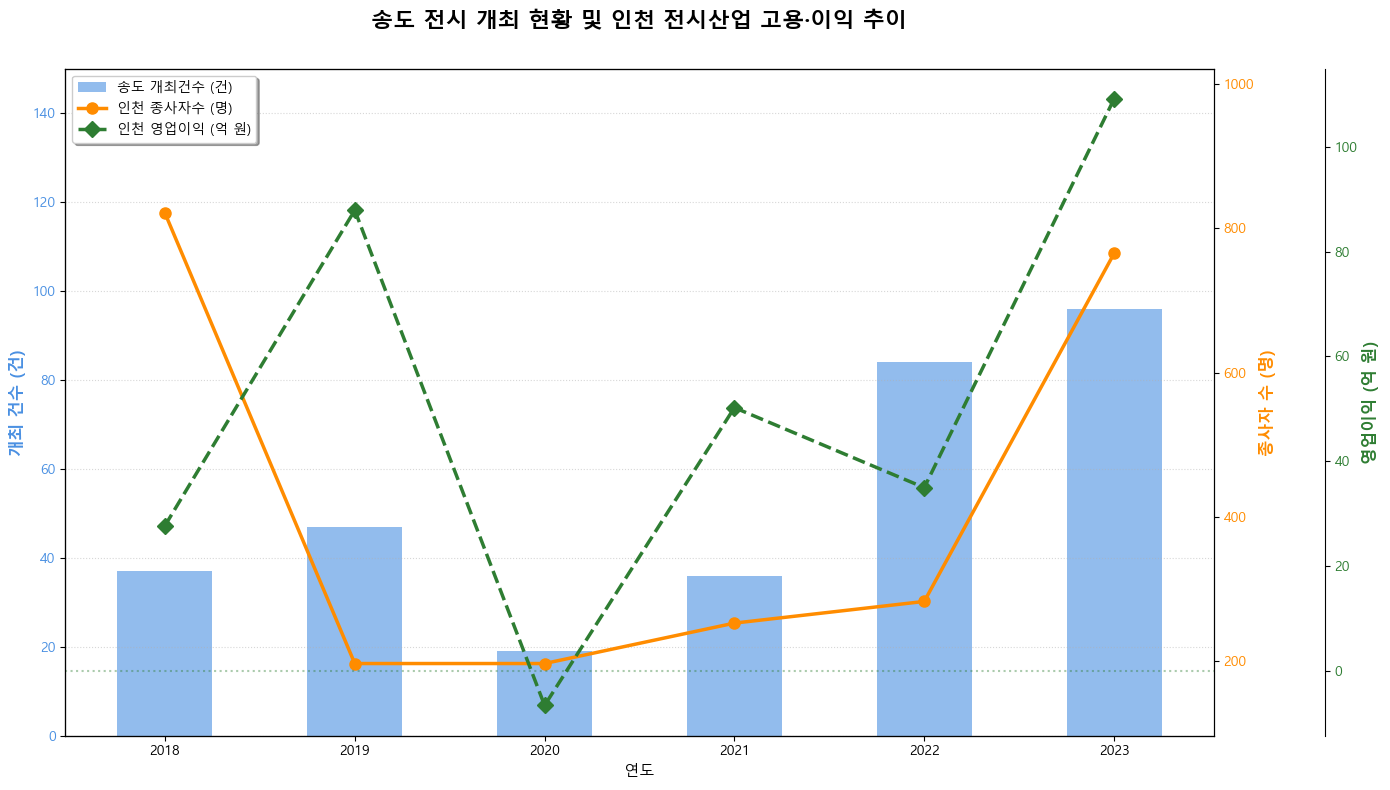

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드
file_worker = '전시사업자지역_업종별_사업체수_전시관련종사자수_2018~2023.xlsx'
file_revenue_profit = '전시사업자_업종_및_지역별_전시_관련_매출액__영업이익_20260410110142.xlsx'
file_songdo_csv = '송도 연별 개최건수.csv'

df_worker = pd.read_excel(file_worker, sheet_name='데이터')
df_profit = pd.read_excel(file_revenue_profit, sheet_name='데이터')
df_songdo = pd.read_csv(file_songdo_csv)

# 2. 데이터 전처리
years = ['2018', '2019', '2020', '2021', '2022', '2023']

# (1) 송도 개최 건수
songdo_counts = df_songdo.set_index('연도').loc['전시회 개최수', years].values.astype(int)

# (2) 인천 지역 종사자 수
worker_row = df_worker[df_worker['특성별(2)'] == '인천'].iloc[0]
worker_values = [worker_row[f'{y}.1'] if f'{y}.1' in worker_row else worker_row[y] for y in years]

# (3) 인천 지역 영업이익 (백만 원 -> 억 원)
rev_profit_row = df_profit[df_profit['특성별(2)'] == '인천'].iloc[0]
profit_in_billion = [float(rev_profit_row[f'{y}.1']) / 100 for y in years]

# 3. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(14, 8))
# 오른쪽 축이 두 개이므로 여백을 충분히 확보합니다.
plt.subplots_adjust(right=0.8)

# --- AX1: 송도 개최건수 (왼쪽 Y축 / 파란색) ---
color_songdo = '#4A90E2' # 파란색
ax1.bar(years, songdo_counts, color=color_songdo, label='송도 개최건수 (건)', width=0.5, alpha=0.6)
ax1.set_xlabel('연도', fontsize=11)
ax1.set_ylabel('개최 건수 (건)', fontsize=12, fontweight='bold', color=color_songdo)
ax1.set_ylim(0, 150)
ax1.tick_params(axis='y', labelcolor=color_songdo)

# --- AX2: 인천 종사자 수 (오른쪽 첫 번째 Y축 / 주황색) ---
ax2 = ax1.twinx()
color_worker = '#FF8C00' # 주황색
line_worker = ax2.plot(years, worker_values, color=color_worker, marker='o', 
                       linewidth=2.5, markersize=8, label='인천 종사자수 (명)')
ax2.set_ylabel('종사자 수 (명)', fontsize=12, fontweight='bold', color=color_worker)
ax2.set_ylim(min(worker_values) - 100, max(worker_values) + 200)
ax2.tick_params(axis='y', labelcolor=color_worker)

# --- AX3: 인천 영업이익 (오른쪽 두 번째 Y축 / 초록색) ---
ax3 = ax1.twinx()
color_profit = '#2E7D32' # 초록색
# 세 번째 축을 오른쪽으로 80포인트 이동시켜 겹치지 않게 합니다.
ax3.spines['right'].set_position(('outward', 80)) 
line_profit = ax3.plot(years, profit_in_billion, color=color_profit, marker='D', 
                       linestyle='--', linewidth=2.5, markersize=8, label='인천 영업이익 (억 원)')
ax3.set_ylabel('영업이익 (억 원)', fontsize=12, fontweight='bold', color=color_profit)
ax3.tick_params(axis='y', labelcolor=color_profit)

# 영업이익 적자/흑자 기준선 (0점 조절)
ax3.axhline(0, color=color_profit, linestyle=':', alpha=0.4)

# 4. 마무리 설정
plt.title('송도 전시 개최 현황 및 인천 전시산업 고용·이익 추이', pad=30, fontsize=16, fontweight='bold')

# 범례 통합 (막대 + 꺾은선 2개)
lines = line_worker + line_profit
labels = [l.get_label() for l in lines]
ax1.legend([ax1.patches[0]] + lines, ['송도 개최건수 (건)'] + labels, 
           loc='upper left', frameon=True, shadow=True)

ax1.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
#6

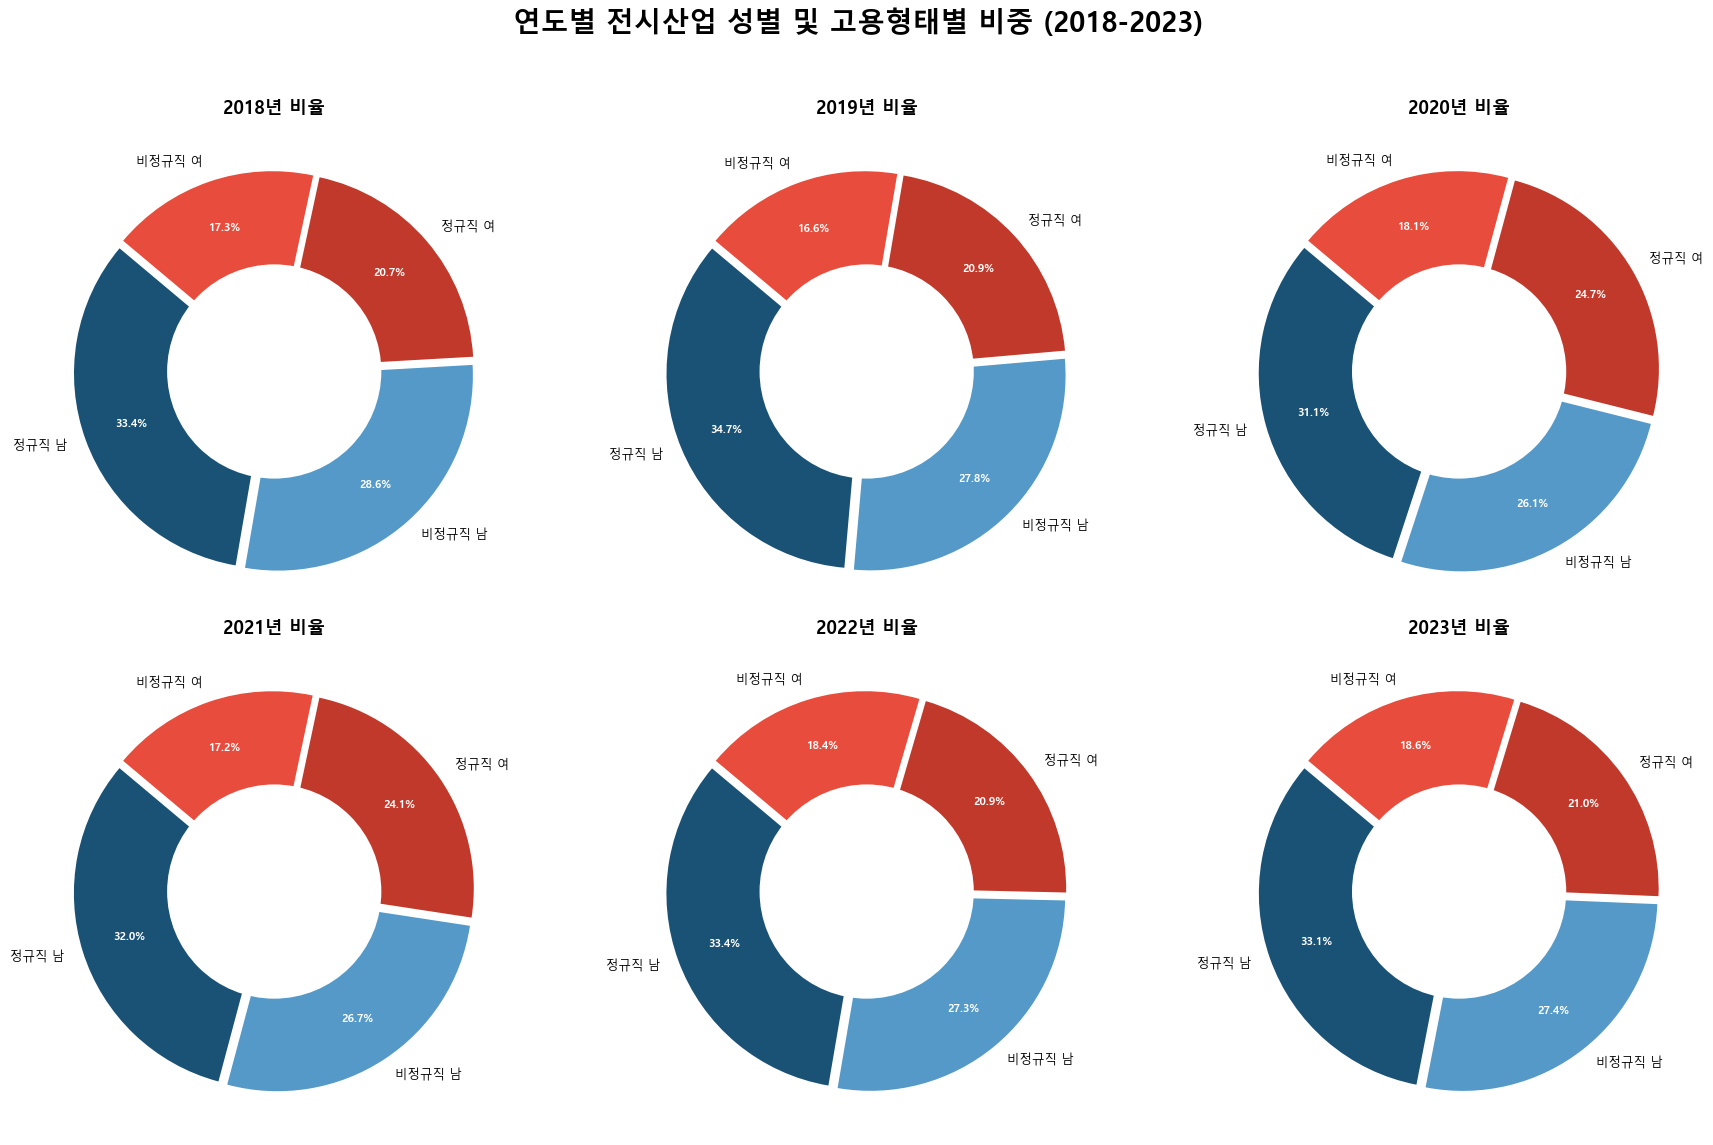

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

# openpyxl 관련 스타일 경고 무시
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# 1. 데이터 로드
file_path = '전시사업자_업종_및_지역별__고용형태별_2018_2023.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터')

# 2. 데이터 추출 설정
target_row = df[df['특성별(1)'] == '전체'].iloc[0]

years = ['2018', '2019', '2020', '2021', '2022', '2023']
labels = ['정규직 남', '비정규직 남', '정규직 여', '비정규직 여']
colors = ['#1a5276', '#5499c7', '#c0392b', '#e74c3c']

# 3. 시각화 설정 (2행 3열 구성)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # 2D 배열을 1D로 평탄화하여 반복문 사용 용이하게 함

for i, year in enumerate(years):
    # 각 연도별 데이터 시작 인덱스 계산 (2018년이 인덱스 2부터 시작, 연도당 12개 컬럼)
    # 정규직 남: base + 1, 정규직 여: base + 2
    # 비정규직 남: base + 4, 비정규직 여: base + 5
    base_idx = 2 + (i * 12)
    
    val_year = np.array([
        float(target_row.iloc[base_idx + 1]), # 정규직 남
        float(target_row.iloc[base_idx + 4]), # 비정규직 남
        float(target_row.iloc[base_idx + 2]), # 정규직 여
        float(target_row.iloc[base_idx + 5])  # 비정규직 여
    ])
    
    # 파이차트 그리기
    wedges, texts, autotexts = axes[i].pie(
        val_year, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        pctdistance=0.75,
        explode=(0.03, 0.03, 0.03, 0.03),
        textprops={'fontsize': 9}
    )
    
    # 도넛 형태를 위한 중앙 흰색 원
    centre_circle = plt.Circle((0,0), 0.55, fc='white')
    axes[i].add_artist(centre_circle)
    
    # 텍스트 스타일
    plt.setp(autotexts, size=8, color="white", weight="bold")
    axes[i].set_title(f'{year}년 비율', fontsize=13, fontweight='bold', pad=10)

# 전체 제목 및 레이아웃 조정
plt.suptitle('연도별 전시산업 성별 및 고용형태별 비중 (2018-2023)', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [17]:
#7

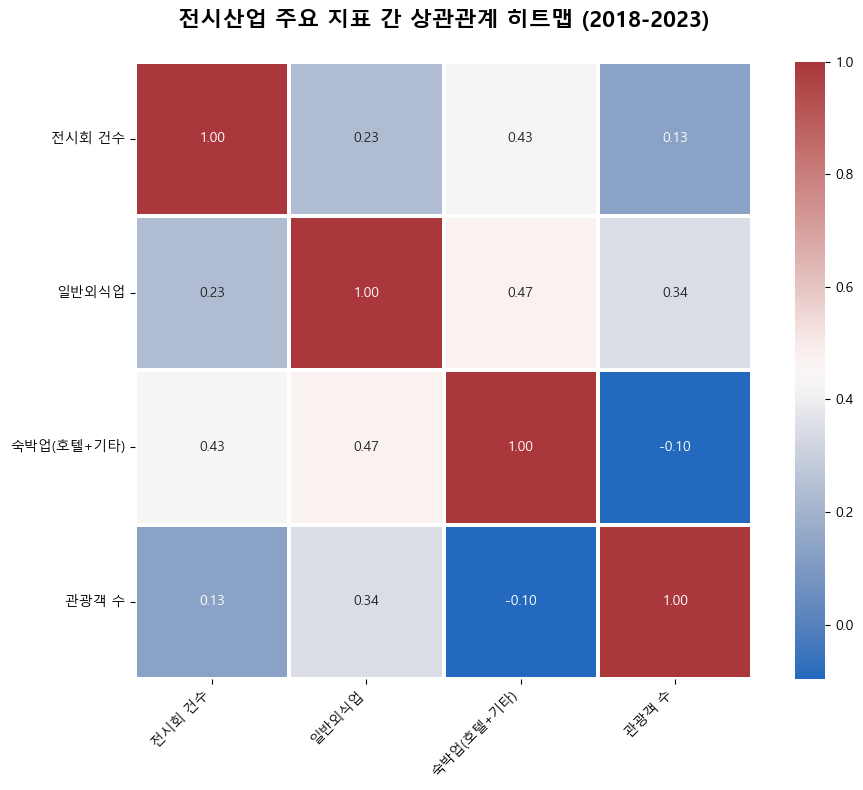

In [22]:
import warnings

# openpyxl 관련 경고를 무시하도록 설정
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. 데이터 로드
file_songdo = '송도 연별 개최건수.csv'
file_profit = '전시사업자_업종_및_지역별_전시_관련_매출액__영업이익_20260410110142.xlsx'
file_employment = '전시사업자_업종_및_지역별__고용형태별_2018_2023.xlsx'

df_songdo = pd.read_csv(file_songdo)
df_profit = pd.read_excel(file_profit, sheet_name='데이터')
df_employment = pd.read_excel(file_employment, sheet_name='데이터')

# 2. 데이터 전처리 및 연도별 통합 (2018-2023)
years = [str(y) for y in range(2018, 2024)]

# (1) 전시회수 (송도)
songdo_data = df_songdo.set_index('연도').loc['전시회 개최수', years].values.astype(float)

# (2) 영업이익 (인천 지역)
profit_row = df_profit[df_profit['특성별(2)'] == '인천'].iloc[0]
profit_data = [float(profit_row[f'{y}.1']) for y in years]

# (3) 종사자수, 정규직, 비정규직 (전체 소계 기준)
emp_row = df_employment[(df_employment['특성별(1)'] == '전체') & (df_employment['특성별(2)'] == '소계')].iloc[0]
worker_data, regular_data, irreg_data = [], [], []

for i in range(6):
    base_idx = 2 + (i * 12)
    worker_data.append(float(emp_row.iloc[base_idx]))      
    regular_data.append(float(emp_row.iloc[base_idx + 1]))  
    irreg_data.append(float(emp_row.iloc[base_idx + 4]))    

# 3. 데이터프레임 병합
combined_df = pd.DataFrame({
    '전시회수': songdo_data,
    '영업이익': profit_data,
    '종사자수': worker_data,
    '정규직': regular_data,
    '비정규직': irreg_data
}, index=years)

# 4. 상관계수 산출
corr_matrix = combined_df.corr()

# 5. 히트맵 시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# --- 참고 이미지의 1번 색상 스타일 적용 (짙은 빨강 - 흰색 - 짙은 파랑) ---
# 1에 가까울수록 진한 빨강(#D32F2F), -1에 가까울수록 진한 파랑(#1976D2)
colors = ["#1976D2", "#FFFFFF", "#D32F2F"] 
custom_cmap = LinearSegmentedColormap.from_list("custom_refined", colors)

plt.figure(figsize=(10, 8))

sns.heatmap(corr, 
            annot=True, 
            fmt=".2f", 
            cmap='vlag',         # 부드러운 감성 테마
            linewidths=1.5,        # 칸 사이를 넓게 벌려서 '조각' 느낌 주기
            linecolor='white',   # 배경과 같은 흰색 선
            square=True)

plt.title('전시산업 주요 지표 간 상관관계 히트맵 (2018-2023)', pad=25, fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# +++++

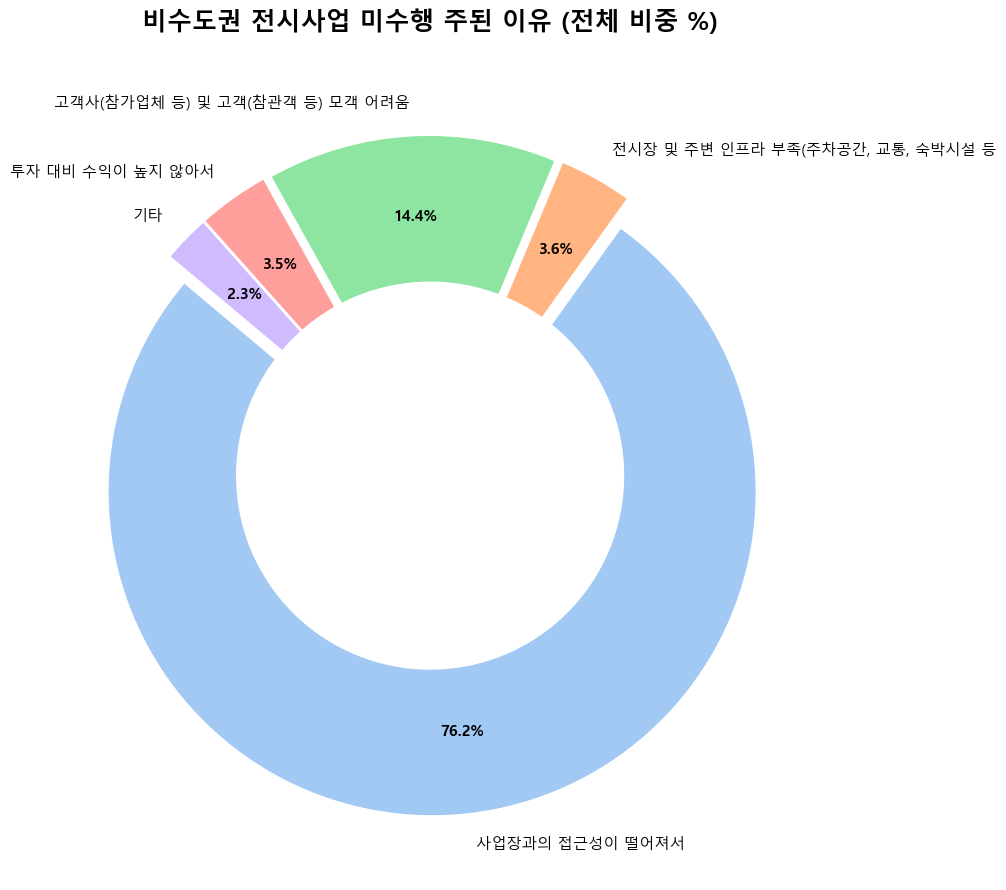

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

# 1. 데이터 로드 (header=1 또는 header=2를 시도해보세요)
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'

# 보통 이런 파일은 2행 혹은 3행부터 진짜 컬럼명이 시작됩니다.
# 데이터가 안 나온다면 header=1을 2나 3으로 바꿔보세요.
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 2. 전처리
# 컬럼명 정리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]

# '사례수'를 제외하고 '(%)'가 포함된 컬럼만 선택
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]

# '전체(소계)' 데이터 추출 (필터링 조건 확인)
total_row = df[df['특성별(2)'].str.contains('소계', na=False)]

if total_row.empty:
    print("데이터를 찾을 수 없습니다. header 설정을 확인해주세요.")
else:
    data_series = total_row[reason_cols].iloc[0].replace('-', 0).astype(float)

    # 3. 시각화 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(12, 9))

    # 색상 및 라벨 설정
    colors = sns.color_palette('pastel')[0:len(reason_cols)]
    labels = [c.replace(' (%)', '') for c in reason_cols]

    # 파이 차트 그리기
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=[0.05] * len(reason_cols),
        pctdistance=0.75,
        textprops={'fontsize': 11}
    )

    # 도넛 형태를 위한 중앙 흰색 원 추가
    centre_circle = plt.Circle((0,0), 0.60, fc='white')
    plt.gca().add_artist(centre_circle)

    # 숫자 텍스트 강조
    plt.setp(autotexts, size=11, weight="bold")

    plt.title('비수도권 전시사업 미수행 주된 이유 (전체 비중 %)', fontsize=18, fontweight='bold', pad=30)
    plt.tight_layout()
    plt.show()

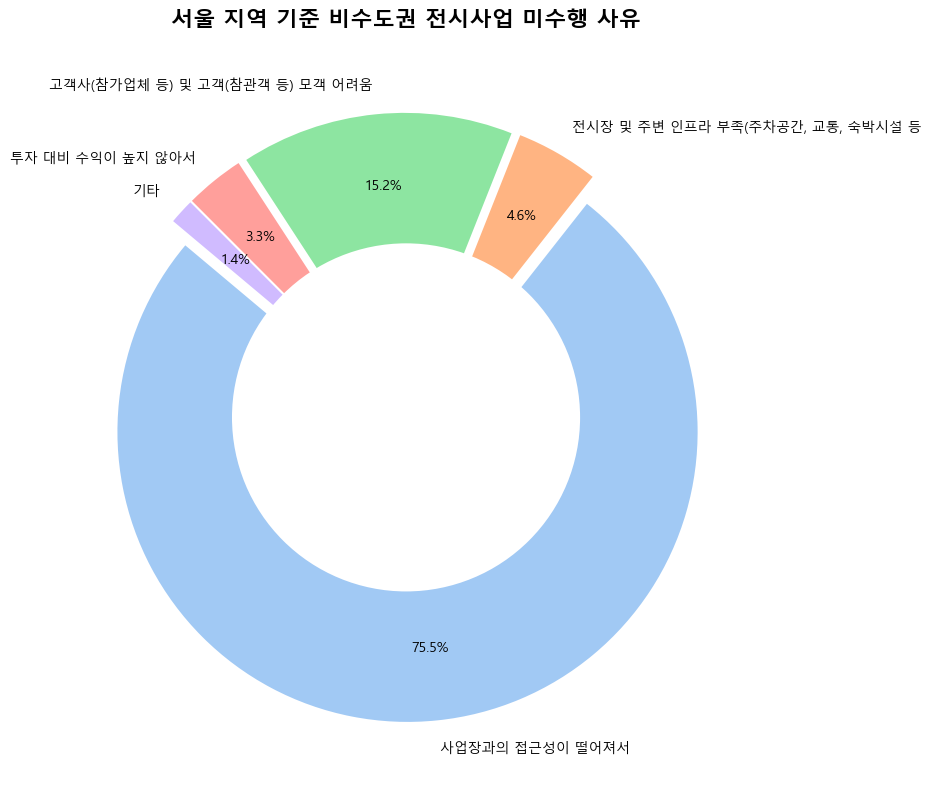

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 환경 설정 및 경고 무시
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 (Header 위치를 1로 지정하여 메타 정보 제외)
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 3. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]

# '서울' 데이터 행 추출
seoul_row = df[df['특성별(2)'].str.contains('서울', na=False)]

# 4. 시각화 로직
if seoul_row.empty:
    print("엑셀 파일 내에서 '서울' 지역을 찾을 수 없습니다.")
else:
    # 수치 데이터 변환 ('-'를 0으로)
    data_series = seoul_row[reason_cols].iloc[0].replace('-', 0).astype(float)
    
    # 합계가 0인 경우 (데이터가 없는 수도권 지역의 특징)
    if data_series.sum() == 0:
        print("서울은 수도권 지역으로, 비수도권 사업 미수행 조사 대상이 아닙니다. (데이터 모두 0)")
        
        # 데이터가 없어도 차트 모양을 보고 싶을 때를 위한 가상 데이터 (모두 동일 비율)
        # 실제 데이터로 보고 싶다면 '경북'이나 '부산'으로 지역명을 바꿔보세요.
        print("대신 차트 구성을 위해 빈 틀을 출력합니다.")
    
    plt.figure(figsize=(10, 8))
    colors = sns.color_palette('pastel')[0:len(reason_cols)]
    labels = [c.replace(' (%)', '') for c in reason_cols]

    # 파이 차트 그리기
    plt.pie(
        data_series if data_series.sum() > 0 else [1]*len(reason_cols), # 데이터 없으면 균등 분할 표시
        labels=labels,
        autopct='%1.1f%%' if data_series.sum() > 0 else '', # 데이터 있을 때만 수치 표시
        startangle=140,
        colors=colors,
        explode=[0.05] * len(reason_cols),
        pctdistance=0.75
    )

    # 도넛 형태
    centre_circle = plt.Circle((0,0), 0.60, fc='white')
    plt.gca().add_artist(centre_circle)

    plt.title('서울 지역 기준 비수도권 전시사업 미수행 사유', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

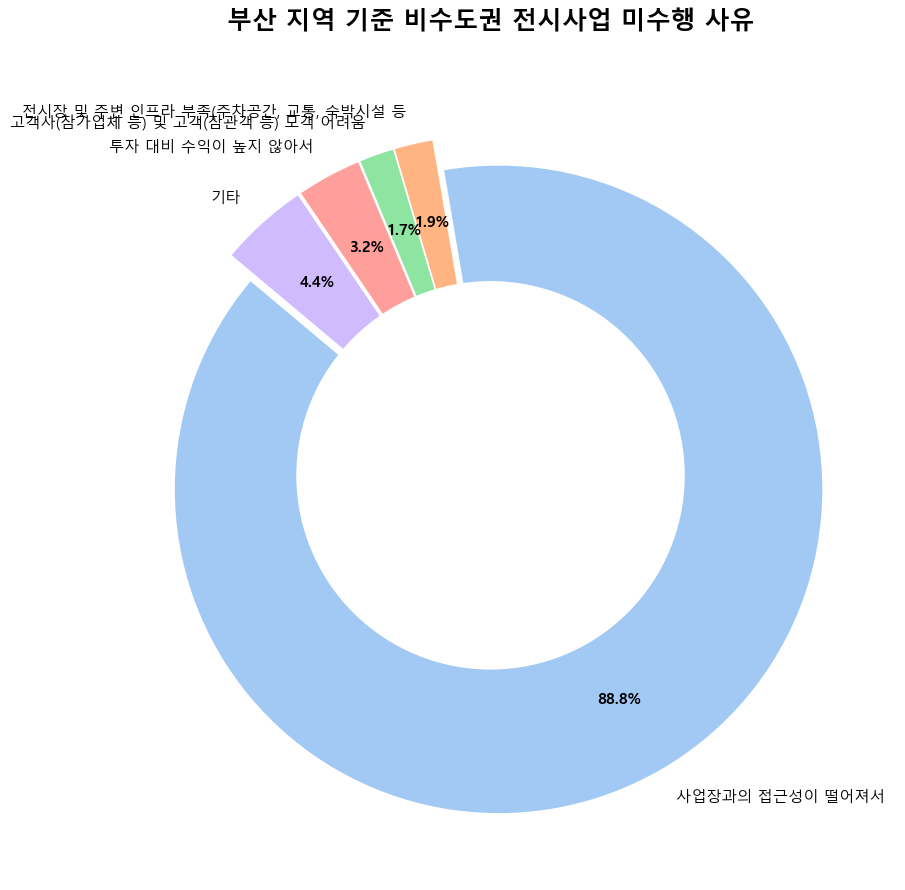

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 환경 설정 및 경고 무시
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 (header=1 설정 필수)
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 3. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
# 사례수 제외, 퍼센트(%) 컬럼만 필터링
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]

# '부산' 데이터 행 추출
busan_row = df[df['특성별(2)'].str.contains('부산', na=False)]

# 4. 시각화 로직
if busan_row.empty:
    print("엑셀 파일 내에서 '부산' 지역을 찾을 수 없습니다. 특성별(2) 컬럼의 이름을 확인해주세요.")
else:
    # 수치 데이터 변환 ('-'를 0으로)
    data_series = busan_row[reason_cols].iloc[0].replace('-', 0).astype(float)
    
    plt.figure(figsize=(12, 9))
    colors = sns.color_palette('pastel')[0:len(reason_cols)]
    labels = [c.replace(' (%)', '') for c in reason_cols]

    # 파이 차트 그리기
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=[0.05] * len(reason_cols),
        pctdistance=0.75,
        textprops={'fontsize': 11}
    )

    # 도넛 형태를 위한 중앙 흰색 원 추가
    centre_circle = plt.Circle((0,0), 0.60, fc='white')
    plt.gca().add_artist(centre_circle)

    # 수치 텍스트 강조
    plt.setp(autotexts, size=11, weight="bold")

    plt.title('부산 지역 기준 비수도권 전시사업 미수행 사유', fontsize=18, fontweight='bold', pad=30)
    plt.tight_layout()
    plt.show()

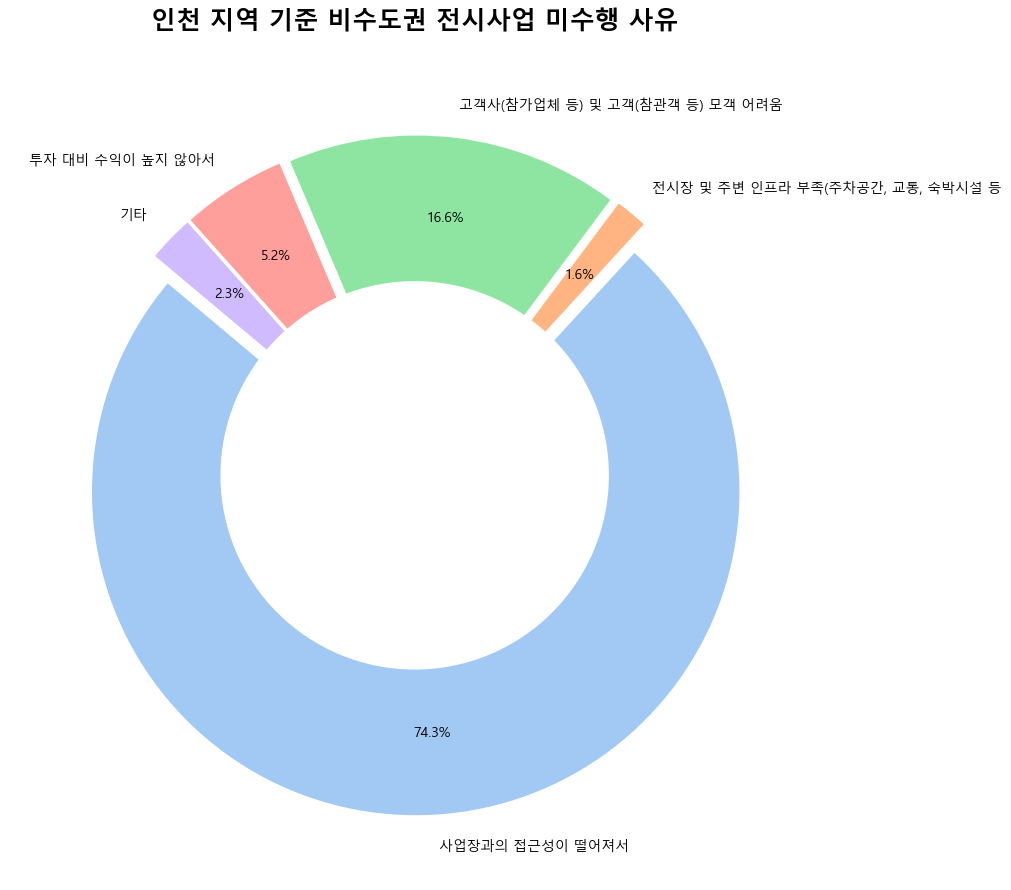

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 환경 설정 및 경고 무시
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 (header=1 설정 필수)
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 3. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]

# '인천' 데이터 행 추출
incheon_row = df[df['특성별(2)'].str.contains('인천', na=False)]

# 4. 시각화 로직
if incheon_row.empty:
    print("엑셀 파일 내에서 '인천' 지역을 찾을 수 없습니다.")
else:
    # 수치 데이터 변환 ('-'를 0으로)
    data_series = incheon_row[reason_cols].iloc[0].replace('-', 0).astype(float)
    
    # 데이터가 모두 0인 경우(수도권 특성)에 대한 처리
    has_data = data_series.sum() > 0
    
    plt.figure(figsize=(12, 9))
    colors = sns.color_palette('pastel')[0:len(reason_cols)]
    labels = [c.replace(' (%)', '') for c in reason_cols]

    # 파이 차트 그리기 (데이터가 없으면 안내 문구와 함께 빈 틀 출력)
    wedges, texts, autotexts = plt.pie(
        data_series if has_data else [1]*len(reason_cols), 
        labels=labels,
        autopct='%1.1f%%' if has_data else '', 
        startangle=140,
        colors=colors if has_data else ['#f0f0f0']*len(reason_cols),
        explode=[0.05] * len(reason_cols),
        pctdistance=0.75
    )

    # 도넛 형태
    centre_circle = plt.Circle((0,0), 0.60, fc='white')
    plt.gca().add_artist(centre_circle)

    # 데이터 부재 시 안내 텍스트
    if not has_data:
        plt.text(0, 0, "인천: 수도권 지역으로\n비수도권 조사 데이터 없음", 
                 ha='center', va='center', fontsize=12, fontweight='bold', color='gray')

    plt.title('인천 지역 기준 비수도권 전시사업 미수행 사유', fontsize=18, fontweight='bold', pad=30)
    plt.tight_layout()
    plt.show()

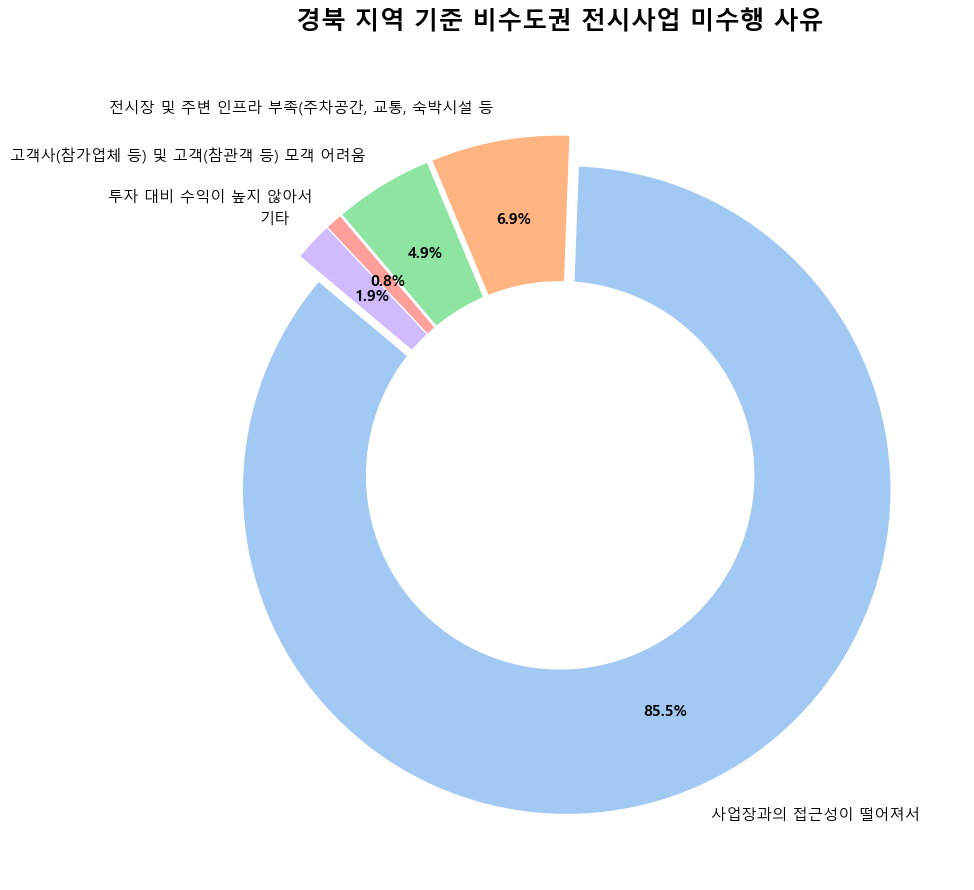

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 환경 설정 및 경고 무시
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 (header=1 설정 유지)
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 3. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
# 사례수 제외, 퍼센트(%) 컬럼만 필터링
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]

# '경북' 데이터 행 추출 (특성별(2) 컬럼 기준)
gb_row = df[df['특성별(2)'].str.contains('경북', na=False)]

# 4. 시각화 로직
if gb_row.empty:
    print("엑셀 파일 내에서 '경북' 지역을 찾을 수 없습니다.")
else:
    # 수치 데이터 변환 ('-'를 0으로)
    data_series = gb_row[reason_cols].iloc[0].replace('-', 0).astype(float)
    
    plt.figure(figsize=(12, 9))
    colors = sns.color_palette('pastel')[0:len(reason_cols)]
    labels = [c.replace(' (%)', '') for c in reason_cols]

    # 파이 차트 그리기
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=[0.05] * len(reason_cols),
        pctdistance=0.75,
        textprops={'fontsize': 11}
    )

    # 도넛 형태를 위한 중앙 흰색 원 추가
    centre_circle = plt.Circle((0,0), 0.60, fc='white')
    plt.gca().add_artist(centre_circle)

    # 수치 텍스트 강조
    plt.setp(autotexts, size=11, weight="bold")

    plt.title('경북 지역 기준 비수도권 전시사업 미수행 사유', fontsize=18, fontweight='bold', pad=30)
    plt.tight_layout()
    plt.show()

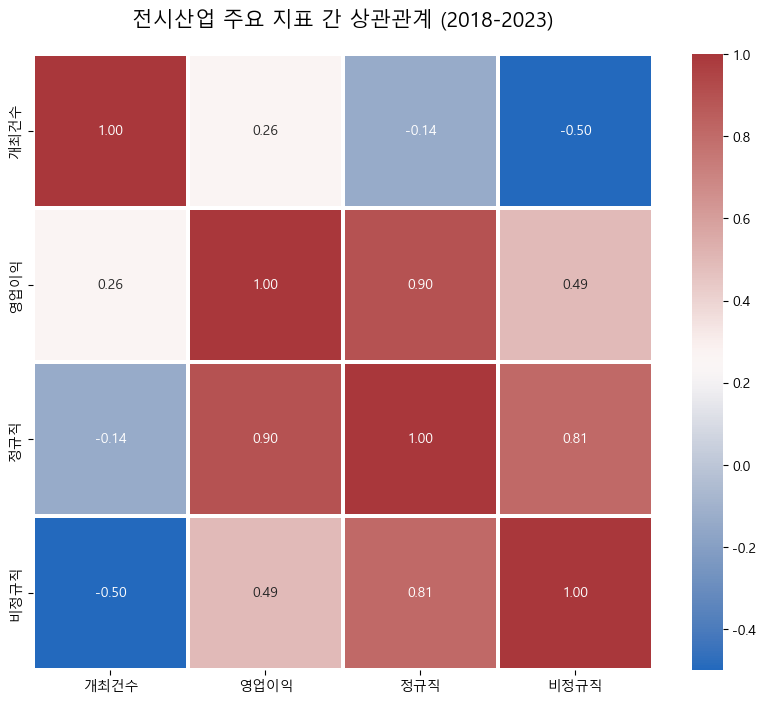

   Year  개최건수    영업이익    정규직  비정규직
0  2018    37  398183  17857  2812
1  2019    47  291648  17312  3966
2  2020    19 -100653   7876  1981
3  2021    36  -50926   8257  2048
4  2022    84  134748   9060  1203
5  2023    96  174109  10011  1367


In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 파일 경로 설정
file_exhibition = '송도 연별 개최건수.xlsx'
file_profit = '전시사업자_업종_및_지역별_전시_관련_매출액__영업이익_20260410110142.xlsx'
file_employment = '전시사업자_업종_및_지역별__고용형태별_2018_2023.xlsx'

# 2. 데이터 로드 및 연도별 정리

# (A) 전시회 개최 건수 (연도별 컬럼 -> 행 변환)
df_ex = pd.read_excel(file_exhibition)
df_ex_melted = df_ex.melt(id_vars=['연도'], var_name='Year', value_name='개최건수')
# 만약 '연도' 행 자체가 데이터라면 아래와 같이 정리
df_ex_final = df_ex.set_index('연도').T.reset_index()
df_ex_final.columns = ['Year', '개최건수']
df_ex_final['Year'] = df_ex_final['Year'].astype(str)

# (B) 영업이익 (멀티 인덱스 처리 및 '소계' 행 추출)
df_pr = pd.read_excel(file_profit, header=[0, 1])
# '전체 - 소계' 행 추출
total_profit = df_pr[(df_pr.iloc[:, 0] == '전체') & (df_pr.iloc[:, 1] == '소계')]
profit_data = []
for col in df_pr.columns:
    if '영업이익' in col[1]:
        year = col[0]
        val = total_profit[col].values[0]
        profit_data.append({'Year': str(year), '영업이익': val})
df_pr_final = pd.DataFrame(profit_data)

# (C) 정규직/비정규직 종사자수
df_em = pd.read_excel(file_employment, header=[0, 1])
total_em = df_em[(df_em.iloc[:, 0] == '전체') & (df_em.iloc[:, 1] == '소계')]
em_data = []

# 멀티 헤더에서 연도와 고용형태 매칭 (데이터 구조에 따라 컬럼명 조정 필요)
for year in range(2018, 2024):
    y_str = str(year)
    # 정규직, 비정규직 컬럼 위치를 찾아 데이터 추출 (예시 구조 기반)
    reg = total_em[(y_str, '정규직')].values[0] if (y_str, '정규직') in total_em.columns else 0
    non_reg = total_em[(y_str, '비정규직')].values[0] if (y_str, '비정규직') in total_em.columns else 0
    em_data.append({'Year': y_str, '정규직': reg, '비정규직': non_reg})
df_em_final = pd.DataFrame(em_data)

# 3. 데이터 통합 (공통 연도 기준)
df_final = pd.merge(df_ex_final, df_pr_final, on='Year')
df_final = pd.merge(df_final, df_em_final, on='Year')

# 수치형 변환 및 결측치 제거
cols_to_corr = ['개최건수', '영업이익', '정규직', '비정규직']
df_final[cols_to_corr] = df_final[cols_to_corr].apply(pd.to_numeric, errors='coerce')
df_final = df_final.dropna()

# 4. 상관계수 계산 및 히트맵 시각화
corr_matrix = df_final[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt='.2f', linewidths=1.5)
plt.title('전시산업 주요 지표 간 상관관계 (2018-2023)', fontsize=15, pad=20)
plt.show()

# 데이터 통합 결과 확인용
print(df_final)

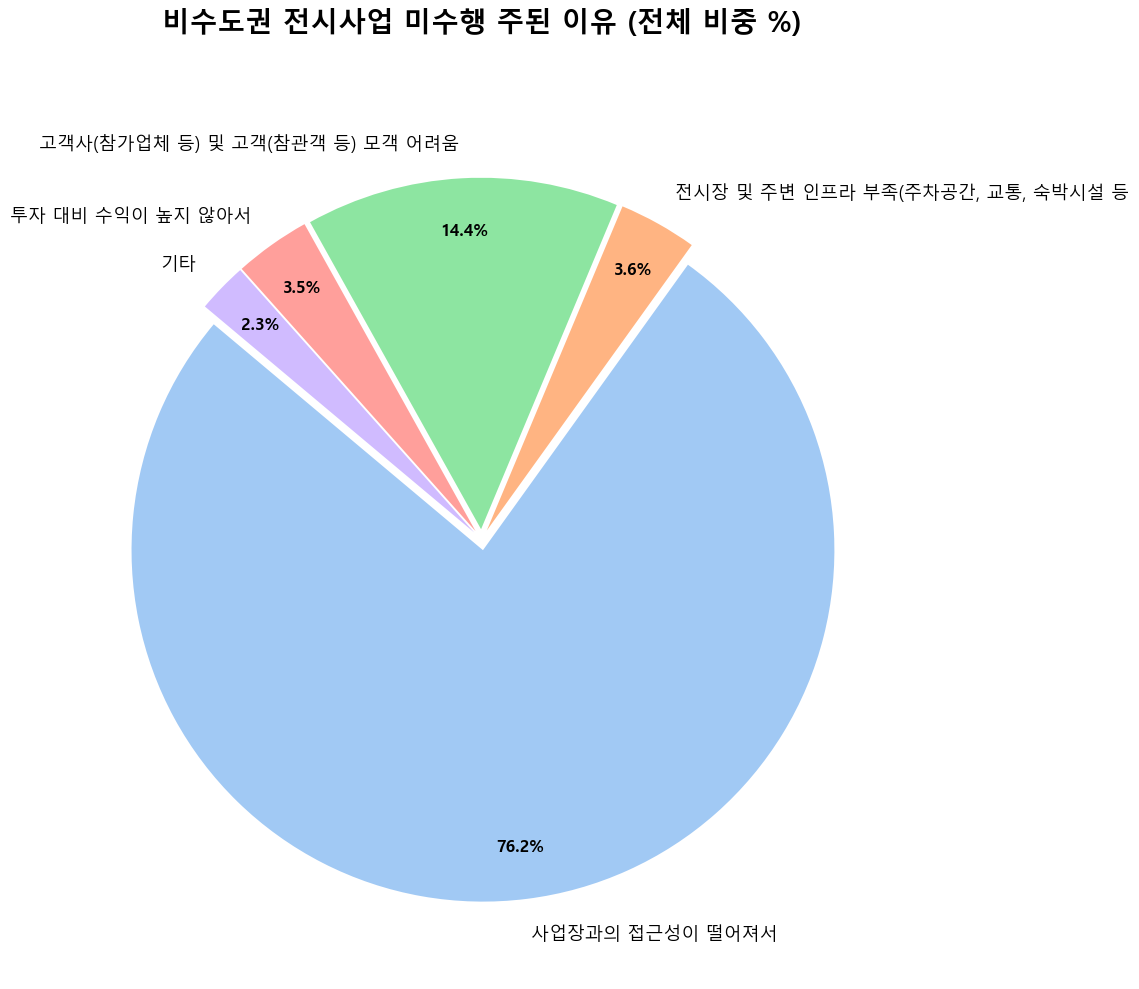

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

# 1. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 2. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]
total_row = df[df['특성별(2)'].str.contains('소계', na=False)]

if total_row.empty:
    print("데이터를 찾을 수 없습니다.")
else:
    data_series = total_row[reason_cols].iloc[0].replace('-', 0).astype(float)

    # 3. 시각화 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    # 캔버스 크기를 넉넉하게 설정하여 텍스트 공간 확보
    plt.figure(figsize=(14, 10))

    # 색상 및 라벨 설정
    colors = sns.color_palette('pastel')[0:len(reason_cols)]
    labels = [c.replace(' (%)', '') for c in reason_cols]

    # 파이 차트 그리기 (중앙 원 제거)
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=[0.03] * len(reason_cols),  # 조각 간격을 약간 좁혀 안정감 부여
        pctdistance=0.85,                   # 수치 표시를 바깥쪽으로 (글자 겹침 방지)
        labeldistance=1.1,                  # 라벨을 파이 바깥으로 살짝 밀어냄
        textprops={'fontsize': 12}          # 기본 텍스트 크기 상향
    )

    # 퍼센트 수치(숫자) 텍스트 스타일 조정
    plt.setp(autotexts, size=12, weight="bold", color="black")
    
    # 라벨(항목명) 텍스트 크기 조정
    plt.setp(texts, size=13)

    plt.title('비수도권 전시사업 미수행 주된 이유 (전체 비중 %)', fontsize=20, fontweight='bold', pad=50)
    
    # 여백 최적화
    plt.tight_layout()
    plt.show()

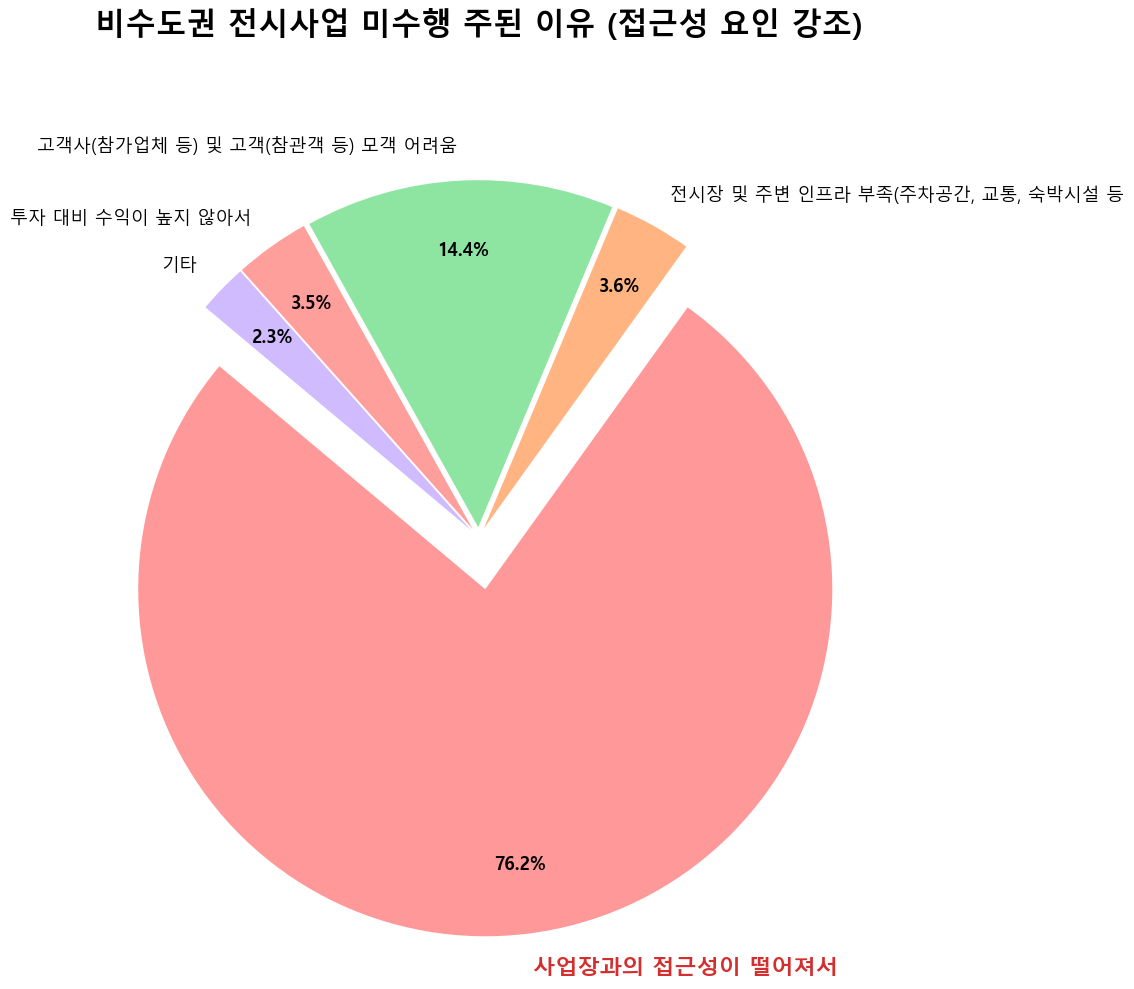

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

# 1. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 2. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]
total_row = df[df['특성별(2)'].str.contains('소계', na=False)]

if total_row.empty:
    print("데이터를 찾을 수 없습니다.")
else:
    data_series = total_row[reason_cols].iloc[0].replace('-', 0).astype(float)

    # 3. 시각화 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(14, 10))

    # 라벨 정리
    labels = [c.replace(' (%)', '') for c in reason_cols]
    
    # 강조 로직 설정
    # 가장 큰 값의 인덱스를 찾아 해당 부분만 더 많이 돌출(explode)시킵니다.
    max_idx = data_series.argmax()
    explode = [0.03] * len(reason_cols)
    explode[max_idx] = 0.15  # 가장 큰 조각(접근성)을 더 밖으로 뺌

    # 색상 설정 (강조할 부분만 더 진한 색상 적용 가능)
    base_colors = sns.color_palette('pastel')[0:len(reason_cols)]
    colors = list(base_colors)
    colors[max_idx] = '#ff9999'  # 강조하고 싶은 조각의 색상을 변경

    # 파이 차트 그리기
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=explode,          # 강조된 explode 적용
        pctdistance=0.8,
        labeldistance=1.1,
        textprops={'fontsize': 12}
    )

    # 텍스트 스타일 조정
    plt.setp(autotexts, size=13, weight="bold")
    plt.setp(texts, size=13)
    
    # 강조된 항목의 텍스트를 더 크게 만들고 빨간색으로 포인트 주기
    texts[max_idx].set_fontsize(16)
    texts[max_idx].set_fontweight('bold')
    texts[max_idx].set_color('#d32f2f')

    plt.title('비수도권 전시사업 미수행 주된 이유 (접근성 요인 강조)', fontsize=22, fontweight='bold', pad=50)
    
    plt.tight_layout()
    plt.show()

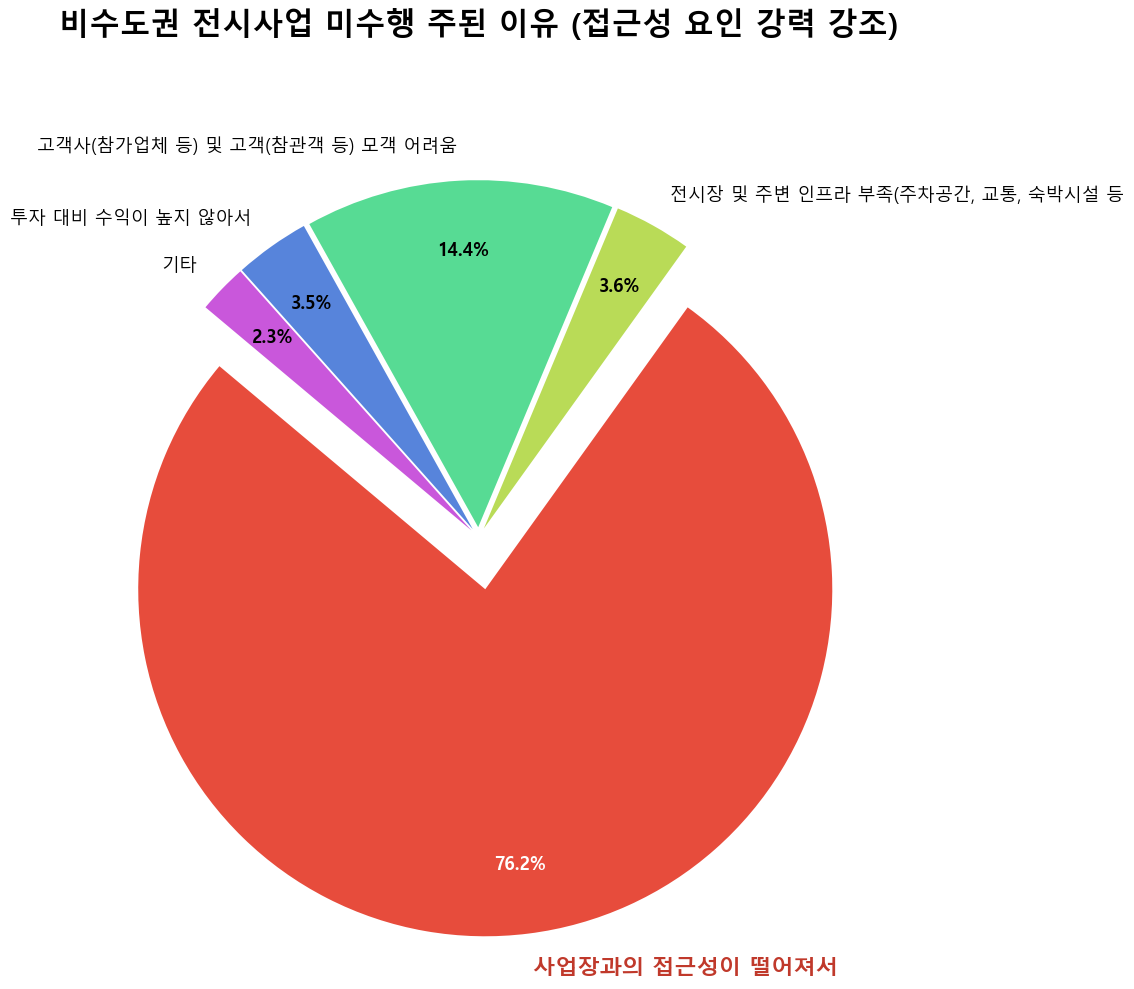

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

# 1. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 2. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]
total_row = df[df['특성별(2)'].str.contains('소계', na=False)]

if total_row.empty:
    print("데이터를 찾을 수 없습니다.")
else:
    data_series = total_row[reason_cols].iloc[0].replace('-', 0).astype(float)

    # 3. 시각화 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(14, 10))

    # 라벨 정리
    labels = [c.replace(' (%)', '') for c in reason_cols]
    
    # 강조 로직 설정
    max_idx = data_series.argmax()
    explode = [0.03] * len(reason_cols)
    explode[max_idx] = 0.15  # 접근성 조각 돌출

    # 색상 설정: 조각 간 구분이 뚜렷한 'hls' 팔레트 사용
    # 강조할 조각은 강렬한 색상으로, 나머지는 서로 겹치지 않는 색상들로 구성합니다.
    base_colors = sns.color_palette('hls', len(reason_cols)) 
    colors = list(base_colors)
    
    # 접근성 조각은 아주 명확한 진한 빨강계열로 고정
    colors[max_idx] = '#E74C3C' 
    
    # 3.5% 등 다른 작은 조각들이 겹치지 않게 인덱스별로 색상 재배치 (예: 파란색, 초록색 등)
    # 리스트에서 색상을 직접 지정할 수도 있습니다.
    # colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F1C40F', '#9B59B6'] # 필요시 직접 지정 가능

    # 파이 차트 그리기
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=explode,
        pctdistance=0.8,
        labeldistance=1.1,
        textprops={'fontsize': 12}
    )

    # 텍스트 스타일 조정
    plt.setp(autotexts, size=13, weight="bold")
    plt.setp(texts, size=13)
    
    # 강조된 항목(접근성)의 텍스트 강조
    texts[max_idx].set_fontsize(16)
    texts[max_idx].set_fontweight('bold')
    texts[max_idx].set_color('#C0392B')
    autotexts[max_idx].set_color('white') # 강조된 진한색 배경 위에서 숫자가 잘 보이게 흰색으로 변경

    plt.title('비수도권 전시사업 미수행 주된 이유 (접근성 요인 강력 강조)', fontsize=22, fontweight='bold', pad=50)
    
    plt.tight_layout()
    plt.show()

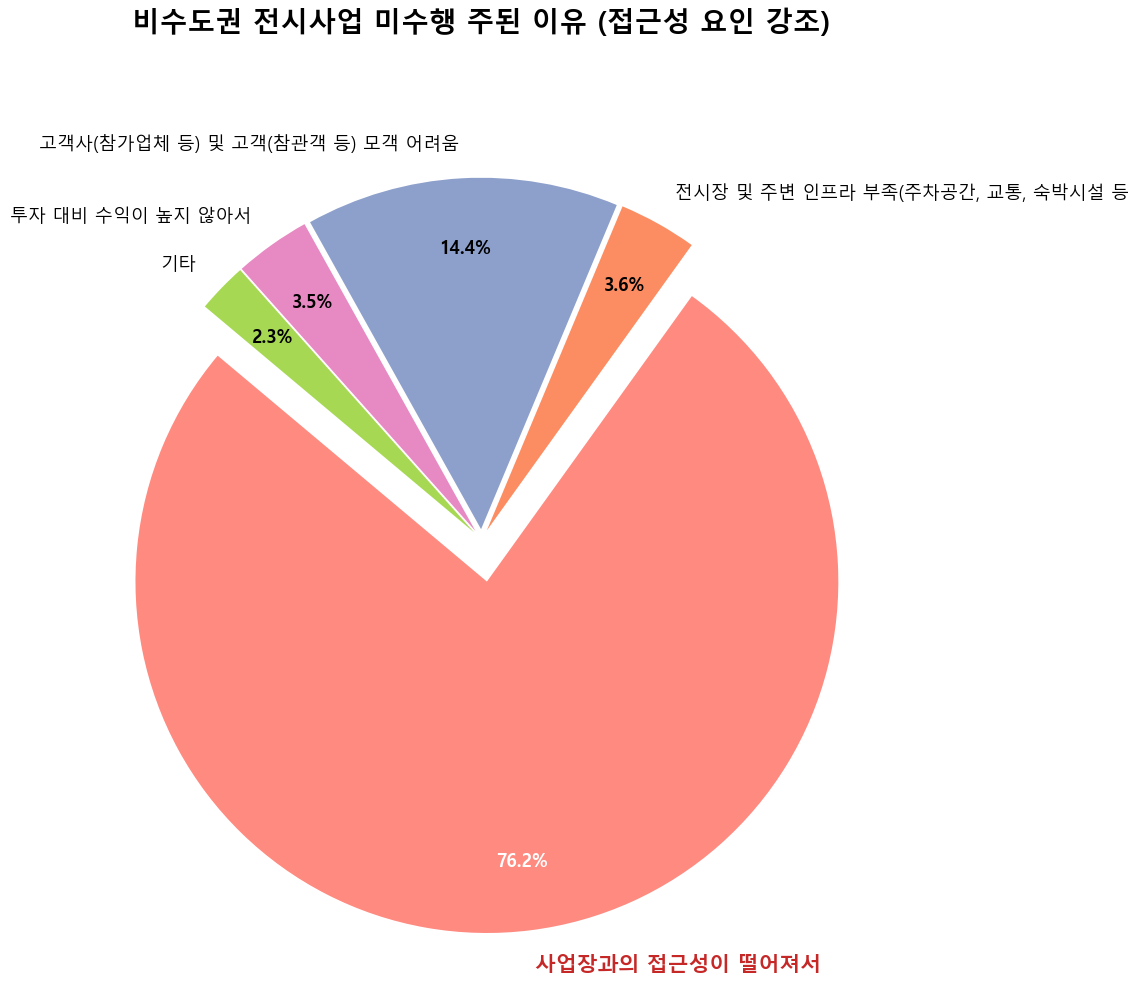

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

# 1. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 2. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]
total_row = df[df['특성별(2)'].str.contains('소계', na=False)]

if total_row.empty:
    print("데이터를 찾을 수 없습니다.")
else:
    data_series = total_row[reason_cols].iloc[0].replace('-', 0).astype(float)

    # 3. 시각화 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(14, 10))

    # 라벨 정리
    labels = [c.replace(' (%)', '') for c in reason_cols]
    
    # 강조 로직 설정 (돌출 강도는 유지)
    max_idx = data_series.argmax()
    explode = [0.03] * len(reason_cols)
    explode[max_idx] = 0.12 

    # 색상 설정: 눈이 편안한 고대비 파스텔톤 팔레트
    # 'Set2'나 'Paired' 팔레트는 색상 구분이 명확하면서도 눈이 덜 아픕니다.
    base_colors = sns.color_palette('Set2', len(reason_cols))
    colors = list(base_colors)
    
    # 강조 조각: 너무 쨍하지 않은 부드러운 코랄/핑크 계열로 변경
    colors[max_idx] = '#ff8a80' # 부드러운 레드-핑크
    
    # 3.5% 항목과 색이 겹치지 않도록 전체적인 색상 순서 조정 (필요 시)
    # colors[2] = '#81c784' # 예: 특정 인덱스의 색상을 직접 부드러운 톤으로 지정 가능

    # 파이 차트 그리기
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=explode,
        pctdistance=0.8,
        labeldistance=1.1,
        textprops={'fontsize': 12}
    )

    # 텍스트 스타일 조정
    plt.setp(autotexts, size=13, weight="bold")
    plt.setp(texts, size=13)
    
    # 강조된 항목(접근성)의 텍스트도 눈이 덜 아픈 진한 갈색/회색 계열로 변경
    texts[max_idx].set_fontsize(15)
    texts[max_idx].set_fontweight('bold')
    texts[max_idx].set_color('#c62828') # 폰트 색상도 톤다운된 레드
    autotexts[max_idx].set_color('white') 

    plt.title('비수도권 전시사업 미수행 주된 이유 (접근성 요인 강조)', fontsize=20, fontweight='bold', pad=50)
    
    plt.tight_layout()
    plt.show()

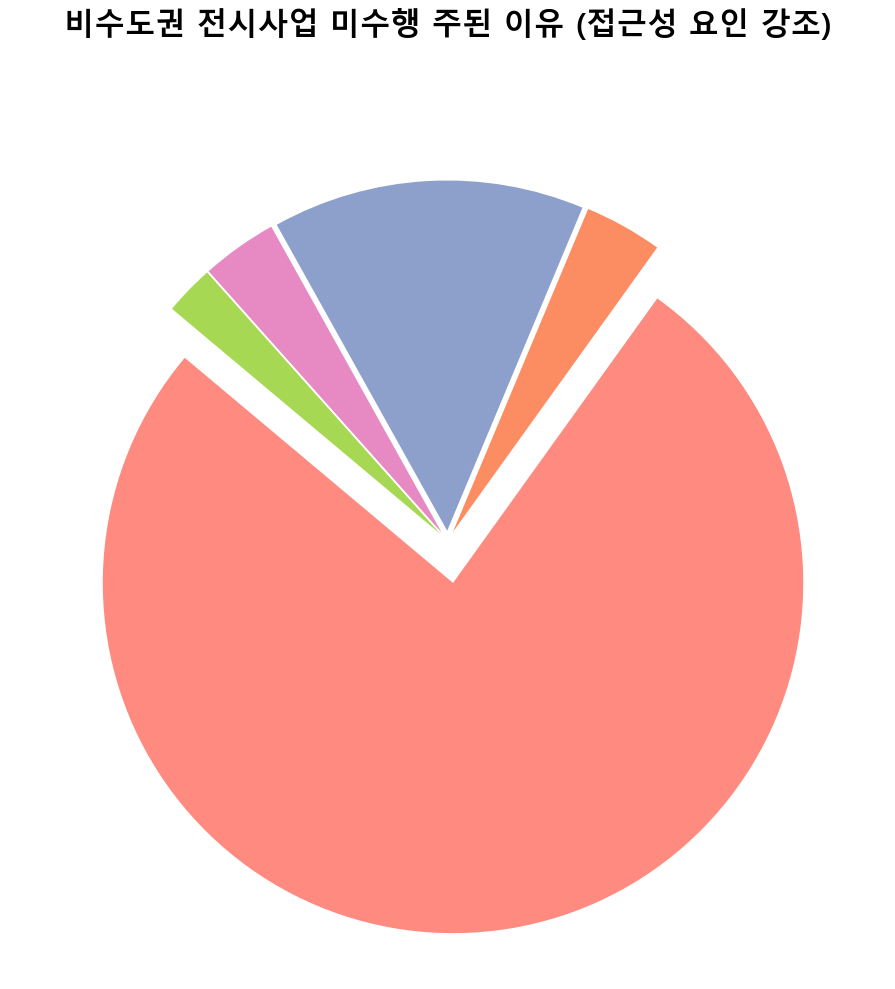

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

# 1. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 2. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]
total_row = df[df['특성별(2)'].str.contains('소계', na=False)]

if total_row.empty:
    print("데이터를 찾을 수 없습니다.")
else:
    data_series = total_row[reason_cols].iloc[0].replace('-', 0).astype(float)

    # 3. 시각화 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(14, 10))

    # 강조 로직 설정
    max_idx = data_series.argmax()
    explode = [0.03] * len(reason_cols)
    explode[max_idx] = 0.12 

    # 색상 설정 (눈이 편안한 파스텔톤)
    colors = list(sns.color_palette('Set2', len(reason_cols)))
    colors[max_idx] = '#ff8a80' # 강조 조각 색상

    # 4. 파이 차트 그리기 (텍스트 제거 버전)
    # labels=None으로 설정하고 autopct를 제거하여 모든 텍스트를 없앱니다.
    plt.pie(
        data_series, 
        labels=None,       # 항목명 제거
        autopct=None,      # 퍼센트 수치 제거
        startangle=140,
        colors=colors,
        explode=explode,
        shadow=False       # 필요 시 입체감을 위해 True로 변경 가능
    )

    # 제목만 남기기
    plt.title('비수도권 전시사업 미수행 주된 이유 (접근성 요인 강조)', fontsize=22, fontweight='bold', pad=50)
    
    plt.tight_layout()
    plt.show()

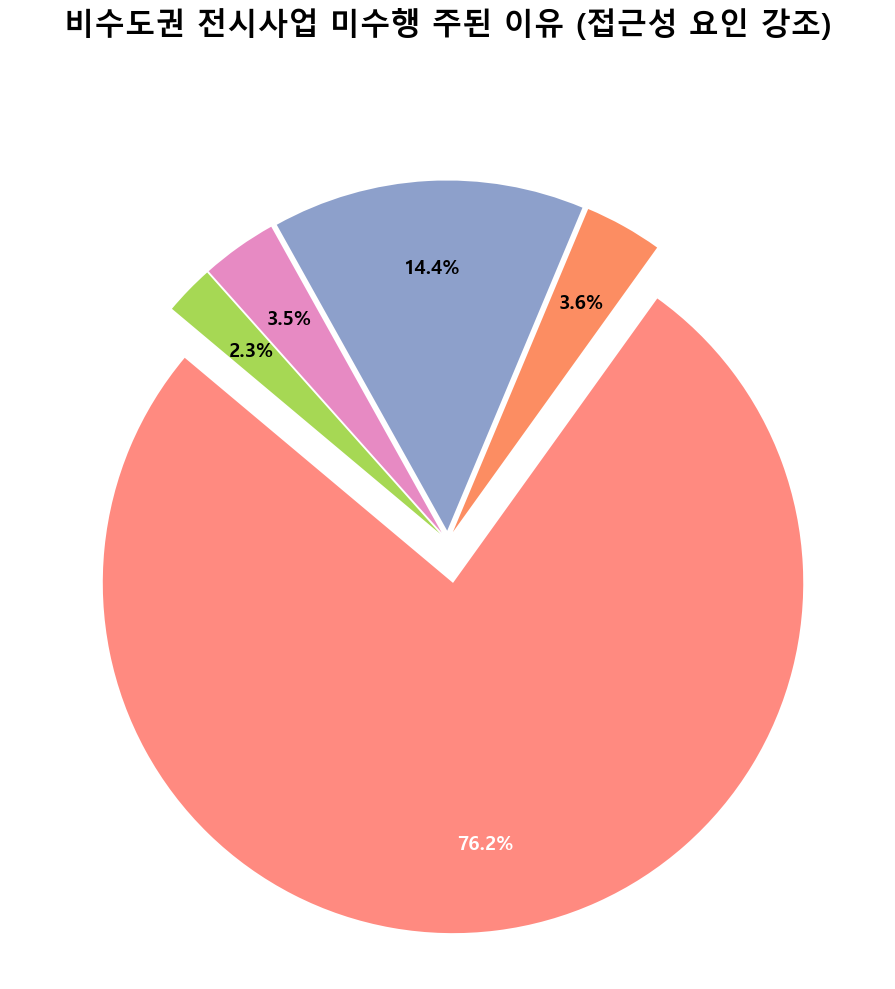

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

# 1. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 2. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]
total_row = df[df['특성별(2)'].str.contains('소계', na=False)]

if total_row.empty:
    print("데이터를 찾을 수 없습니다.")
else:
    data_series = total_row[reason_cols].iloc[0].replace('-', 0).astype(float)

    # 3. 시각화 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(14, 10))

    # 강조 로직 설정
    max_idx = data_series.argmax()
    explode = [0.03] * len(reason_cols)
    explode[max_idx] = 0.12 

    # 색상 설정 (눈이 편안한 파스텔톤)
    colors = list(sns.color_palette('Set2', len(reason_cols)))
    colors[max_idx] = '#ff8a80' # 강조 조각 색상

    # 4. 파이 차트 그리기 (항목명은 없애고 숫자만 남김)
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=None,            # 항목명(텍스트) 제거
        autopct='%1.1f%%',      # 퍼센트 수치는 유지
        startangle=140,
        colors=colors,
        explode=explode,
        pctdistance=0.75,       # 수치가 조각 중앙쯤 오도록 배치
        textprops={'fontsize': 14, 'weight': 'bold'} # 숫자 크기 및 굵기 설정
    )

    # 강조된 조각의 숫자 색상을 흰색으로 변경하여 더 잘 보이게 함
    autotexts[max_idx].set_color('white')

    # 제목 설정
    plt.title('비수도권 전시사업 미수행 주된 이유 (접근성 요인 강조)', fontsize=22, fontweight='bold', pad=50)
    
    plt.tight_layout()
    plt.show()

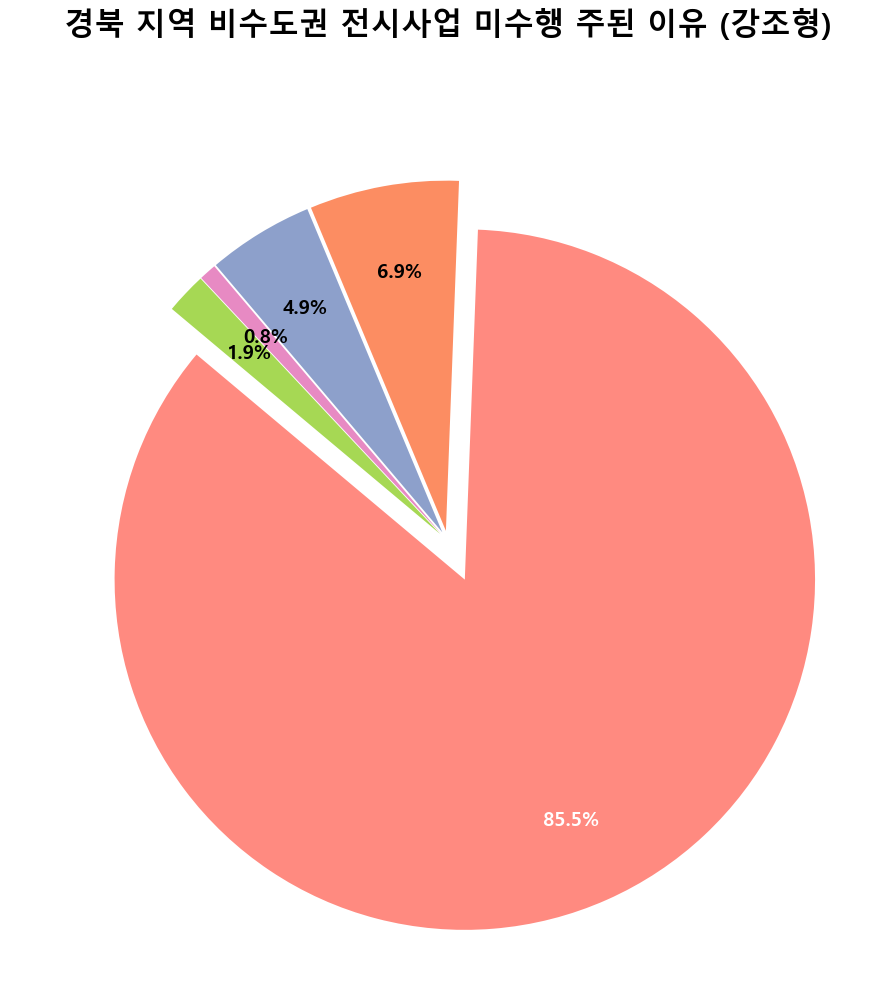

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 환경 설정 및 경고 무시
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 3. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]

# '경북' 데이터 행 추출
gb_row = df[df['특성별(2)'].str.contains('경북', na=False)]

# 4. 시각화 로직
if gb_row.empty:
    print("엑셀 파일 내에서 '경북' 지역을 찾을 수 없습니다.")
else:
    data_series = gb_row[reason_cols].iloc[0].replace('-', 0).astype(float)
    
    plt.figure(figsize=(14, 10))
    
    # 강조 로직 설정 (가장 큰 조각 돌출)
    max_idx = data_series.argmax()
    explode = [0.03] * len(reason_cols)
    explode[max_idx] = 0.12 

    # 색상 설정 (눈이 편안한 파스텔톤)
    colors = list(sns.color_palette('Set2', len(reason_cols)))
    colors[max_idx] = '#ff8a80' # 강조 조각 (부드러운 레드-핑크)

    # 파이 차트 그리기 (텍스트 제거, 숫자 유지)
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=None,            # 항목명 제거
        autopct='%1.1f%%',      # 퍼센트 숫자 유지
        startangle=140,
        colors=colors,
        explode=explode,
        pctdistance=0.75,       # 숫자를 조각 안쪽으로 적절히 배치
        textprops={'fontsize': 14, 'weight': 'bold'}
    )

    # 강조된 조각의 숫자 색상 최적화 (흰색)
    autotexts[max_idx].set_color('white')

    # 중앙 원(도넛 형태) 제거하여 꽉 찬 파이로 변경 (이전 요청 반영)
    
    # 제목 설정
    plt.title('경북 지역 비수도권 전시사업 미수행 주된 이유 (강조형)', fontsize=22, fontweight='bold', pad=50)
    
    plt.tight_layout()
    plt.show()

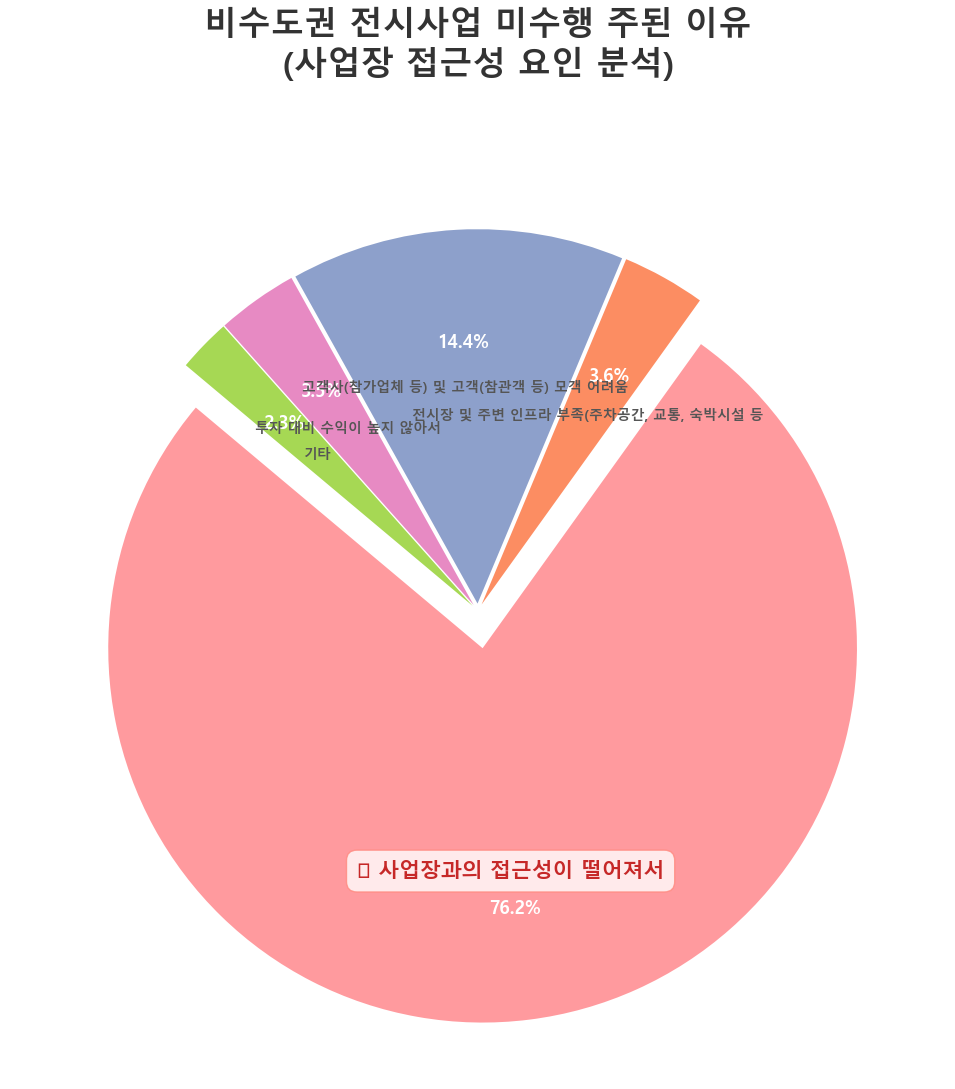

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 환경 설정 및 경고 무시
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 3. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]
total_row = df[df['특성별(2)'].str.contains('소계', na=False)]

if total_row.empty:
    print("데이터를 찾을 수 없습니다.")
else:
    data_series = total_row[reason_cols].iloc[0].replace('-', 0).astype(float)
    labels = [c.replace(' (%)', '') for c in reason_cols]

    plt.figure(figsize=(15, 11))

    # 강조 로직 (가장 큰 값)
    max_idx = data_series.argmax()
    explode = [0.02] * len(reason_cols)
    explode[max_idx] = 0.1  # 강조 조각만 살짝 더 돌출

    # 색상 설정 (이미지와 유사한 톤)
    colors = list(sns.color_palette('Set2', len(reason_cols)))
    colors[max_idx] = '#ff9a9e' # 부드러운 코랄 핑크

    # 4. 파이 차트 그리기
    # 텍스트를 수동으로 제어하기 위해 기본 라벨은 비웁니다.
    wedges, texts, autotexts = plt.pie(
        data_series, 
        startangle=140,
        colors=colors,
        explode=explode,
        autopct='%1.1f%%',
        pctdistance=0.7,
        textprops={'fontsize': 13, 'weight': 'bold', 'color': 'white'} # 숫자 스타일
    )

    # 5. 이미지 스타일처럼 항목명(라벨)을 차트 내부에 배치
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = 0.5 * plt.np.sin(plt.np.deg2rad(ang))
        x = 0.5 * plt.np.cos(plt.np.deg2rad(ang))
        
        # 강조 조각일 경우 텍스트를 더 크게, 박스 처리
        if i == max_idx:
            plt.text(x*1.4, y*1.4, f"📍 {labels[i]}", ha='center', va='center', 
                     fontsize=15, weight='bold', color='#c62828',
                     bbox=dict(facecolor='white', edgecolor='#ff8a80', boxstyle='round,pad=0.5', alpha=0.8))
        else:
            # 나머지 조각들 라벨 (숫자 위에 작게 표시)
            plt.text(x*1.2, y*1.2, labels[i], ha='center', va='center', 
                     fontsize=10, color='#555555', weight='semibold')

    plt.title('비수도권 전시사업 미수행 주된 이유\n(사업장 접근성 요인 분석)', 
              fontsize=24, fontweight='bold', pad=50, color='#333333')
    
    plt.tight_layout()
    plt.show()

KeyError: 0

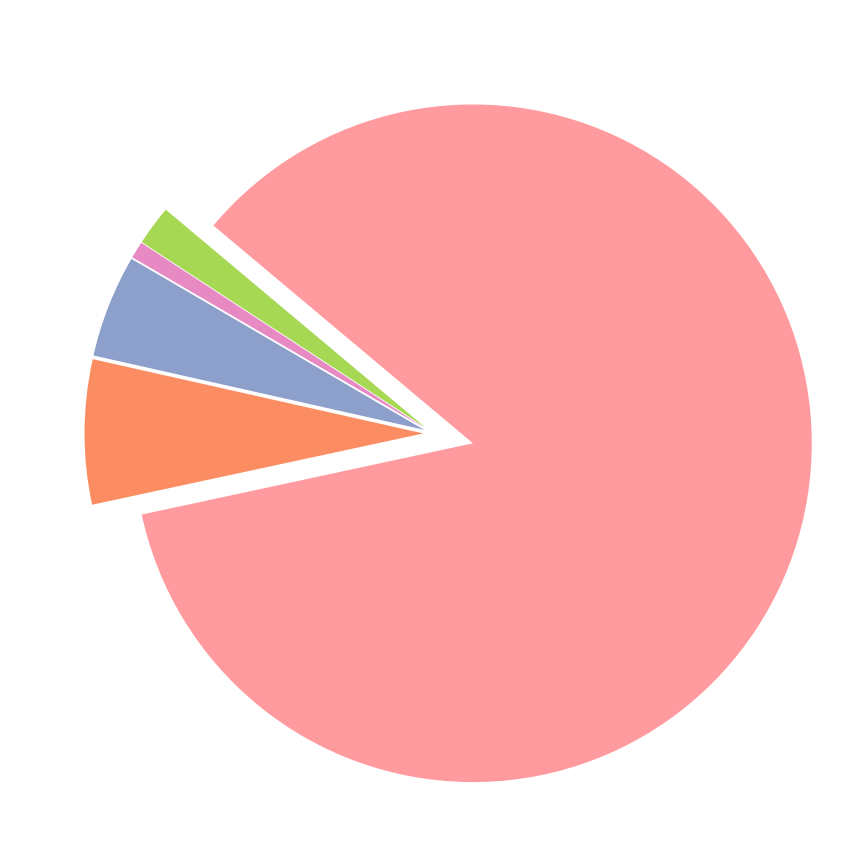

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np

# 1. 환경 설정 및 경고 무시
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 3. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]
gb_row = df[df['특성별(2)'].str.contains('경북', na=False)]

if gb_row.empty:
    print("경북 데이터를 찾을 수 없습니다.")
else:
    data_series = gb_row[reason_cols].iloc[0].replace('-', 0).astype(float)
    labels = [c.replace(' (%)', '') for c in reason_cols]

    fig, ax = plt.subplots(figsize=(15, 11))

    # 강조 로직 및 색상 설정
    max_idx = data_series.argmax()
    explode = [0.03] * len(reason_cols)
    explode[max_idx] = 0.12 
    colors = list(sns.color_palette('Set2', len(reason_cols)))
    colors[max_idx] = '#ff9a9e' # 부드러운 강조 색상

    # 파이 차트 그리기 (기본 라벨과 숫자는 여기서 끕니다)
    wedges, _ = ax.pie(
        data_series, 
        startangle=140,
        colors=colors,
        explode=explode,
        labels=None, 
        counterclock=False # 시계 방향으로 배치
    )

    # 4. 이미지처럼 각 조각 옆에 라벨과 숫자 표시하기
    for i, p in enumerate(wedges):
        # 조각의 각도 계산
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        
        # 텍스트 배치 위치 설정 (수평 정렬 결정)
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        
        # 강조 여부에 따른 텍스트 스타일
        val = data_series[i]
        label_text = f"{labels[i]}\n({val}%)"
        
        if i == max_idx:
            # 강조 항목: 아이콘 추가 및 굵은 글씨
            ax.annotate(f"📍 {label_text}", xy=(x, y), xytext=(1.35*np.sign(x), 1.2*y),
                        horizontalalignment=horizontalalignment,
                        fontsize=14, weight='bold', color='#c62828',
                        arrowprops=dict(arrowstyle="-", color='#ff8a80', lw=1.5))
        else:
            # 일반 항목: 깔끔한 지시선과 텍스트
            ax.annotate(label_text, xy=(x, y), xytext=(1.3*np.sign(x), 1.15*y),
                        horizontalalignment=horizontalalignment,
                        fontsize=11, color='#444444',
                        arrowprops=dict(arrowstyle="-", color='#aaaaaa'))

    # 제목 설정
    plt.title('경북 지역 비수도권 전시사업 미수행 주된 이유', 
              fontsize=22, fontweight='bold', pad=60)
    
    plt.tight_layout()
    plt.show()

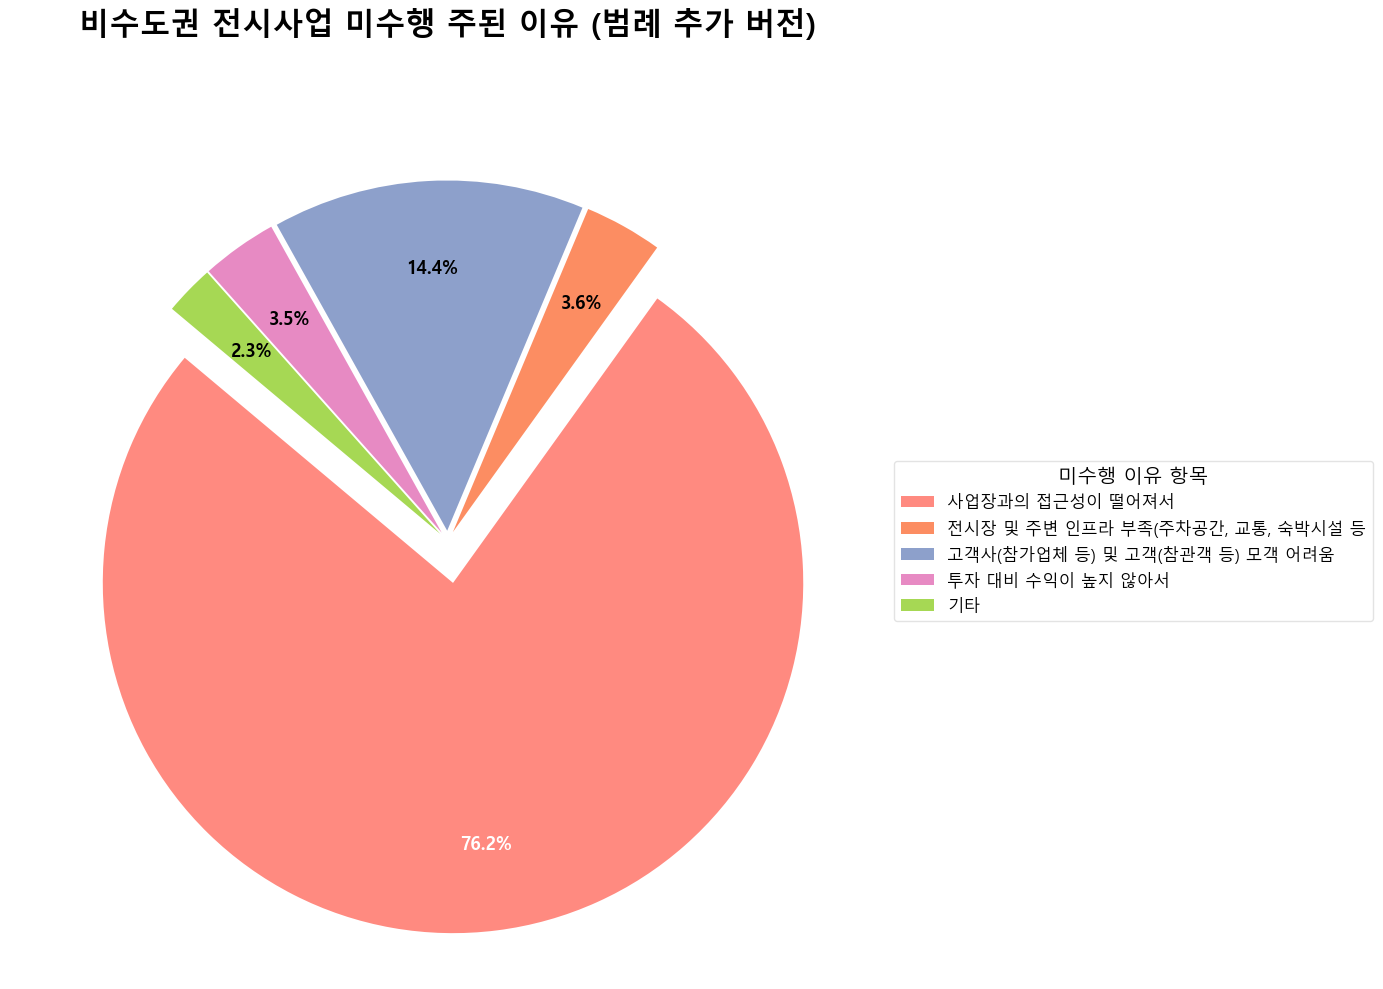

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 환경 설정 및 경고 무시
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
file_path = '비수도권_전시장에서_전시관련_사업_수행하지_않은_주된_이유_20260413162743.xlsx'
df = pd.read_excel(file_path, sheet_name='데이터', header=1)

# 3. 전처리
df.columns = [str(col).replace('\n', ' ').strip() for col in df.columns]
reason_cols = [col for col in df.columns if '(%)' in col and '사례수' not in col]
total_row = df[df['특성별(2)'].str.contains('소계', na=False)]

if total_row.empty:
    print("데이터를 찾을 수 없습니다.")
else:
    data_series = total_row[reason_cols].iloc[0].replace('-', 0).astype(float)
    labels = [c.replace(' (%)', '') for c in reason_cols]

    plt.figure(figsize=(14, 10))

    # 강조 로직 설정
    max_idx = data_series.argmax()
    explode = [0.03] * len(reason_cols)
    explode[max_idx] = 0.12 

    # 색상 설정 (Set2 팔레트 기반)
    colors = list(sns.color_palette('Set2', len(reason_cols)))
    colors[max_idx] = '#ff8a80' # 강조 조각 색상

    # 4. 파이 차트 그리기
    # 범례에 표시될 이름을 위해 labels 인자를 전달합니다.
    wedges, texts, autotexts = plt.pie(
        data_series, 
        labels=None,          # 차트 주변 텍스트는 범례로 뺄 것이므로 None 설정
        autopct='%1.1f%%',    # 숫자는 남겨둠
        startangle=140,
        colors=colors,
        explode=explode,
        pctdistance=0.75,
        textprops={'fontsize': 13, 'weight': 'bold'}
    )

    # 강조된 조각의 숫자 색상 변경
    autotexts[max_idx].set_color('white')

    # 5. 범례(Legend) 추가
    # bbox_to_anchor를 이용해 차트 우측 바깥에 깔끔하게 배치합니다.
    plt.legend(
        wedges, 
        labels, 
        title="미수행 이유 항목", 
        loc="center left", 
        bbox_to_anchor=(1, 0, 0.5, 1), 
        fontsize=12,
        title_fontsize=14,
        frameon=True,
        edgecolor='#dddddd'
    )

    plt.title('비수도권 전시사업 미수행 주된 이유 (범례 추가 버전)', fontsize=22, fontweight='bold', pad=50)
    
    # 범례가 잘리지 않도록 여백 조정
    plt.tight_layout()
    plt.show()